## Environment Setup

This section imports all libraries used
throughout the notebook.

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.random.set_seed(42)

np.random.seed(42)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## Download Dataset

The dataset is downloaded automatically via `kagglehub`. The notebook then searches
recursively for `creditcard.csv` inside the downloaded directory instead of assuming
any hard-coded local path.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [3]:
df = pd.read_csv(path + "/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploratory Data Analysis

This section characterizes the dataset: its size, class balance, and the distribution
of transaction amounts and time, along with visualizations.

In [4]:
# Dataset Overview
summary = pd.Series({

    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Memory (MB)": round(df.memory_usage(deep=True).sum()/1024**2,2),
    "Missing values": df.isna().sum().sum(),
    "Duplicate rows": df.duplicated().sum()

})

display(summary.to_frame(name="Value"))

,Value
Rows,284807.00
Columns,31.00
Memory (MB),67.36
Missing values,0.00
Duplicate rows,1081.00


In [5]:
# Duplicate records
non_fraud_duplicates = df[df["Class"] == 0].duplicated().sum()
print(f"Count of Duplicates in Non Fraud Class = {non_fraud_duplicates}")

fraud_duplicates = df[df["Class"] == 1].duplicated().sum()
print(f"Count of Duplicates in Fraud Class = {fraud_duplicates}")

print(f"Total Number of Duplicates = {df.duplicated().sum()}")

Count of Duplicates in Non Fraud Class = 1062
Count of Duplicates in Fraud Class = 19
Total Number of Duplicates = 1081


In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [8]:
# Random Sample
display(df.sample(5, random_state=42))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [9]:
# Target Variable Distribution
class_counts = (
    df["Class"]
    .value_counts()
    .rename(index={0: "Non-Fraud", 1: "Fraud"})
)

class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={0: "Non-Fraud", 1: "Fraud"})
    .round(3)
)

target_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages
})

display(target_summary)

,Count,Percentage (%)
Class,,
Non-Fraud,284315,99.827
Fraud,492,0.173


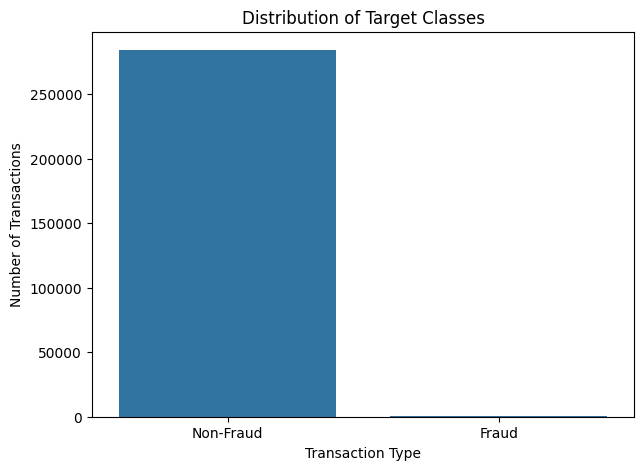

In [10]:
# Class Distribution
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Class"
)

ax.set_xticklabels(["Non-Fraud", "Fraud"])

plt.title("Distribution of Target Classes")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

### Observation
The dataset is extremely imbalanced.

Fraudulent transactions represent only a very small proportion of the entire dataset.

This imbalance should be considered during model development because accuracy alone would provide misleading performance estimates.

Therefore, model performance will primarily be evaluated using Precision, Recall, F1-score, ROC-AUC, and PR-AUC rather than Accuracy.

<Axes: title={'center': 'Time Distribution'}, xlabel='Time', ylabel='Density'>

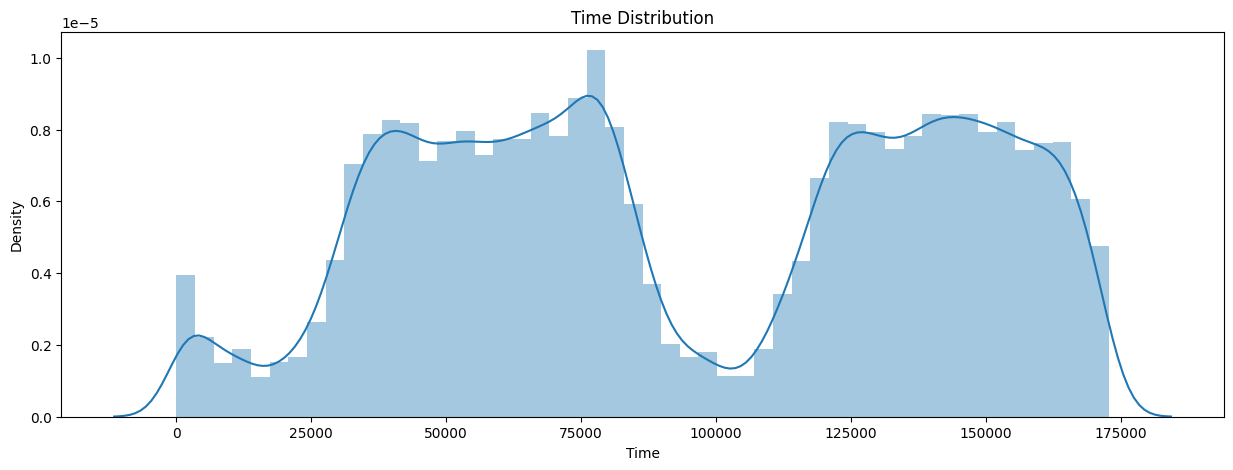

In [11]:
plt.figure(figsize=(15,5))
plt.title('Time Distribution')
sns.distplot(df.Time)

In [12]:
# Dataset Summary
# ==========================================================

dataset_summary = pd.DataFrame({
    "Check": [
        "Number of transactions",
        "Number of features",
        "Target variable",
        "Missing values",
        "Duplicate rows",
        "Data types",
        "Class imbalance"
    ],
    "Result": [
        f"{df.shape[0]:,}",
        df.shape[1] - 1,
        "Binary",
        "None",
        f"{df.duplicated().sum():,}",
        "Numeric",
        "Severe (99.83% / 0.17%)"
    ]
})

dataset_summary.style \
    .hide(axis="index") \
    .set_caption("Dataset Summary") \
    .set_properties(**{
        "text-align": "left",
        "font-size": "12pt"
    })

Check,Result
Number of transactions,"284,807"
Number of features,30
Target variable,Binary
Missing values,None
Duplicate rows,"1,081"
Data types,Numeric
Class imbalance,Severe (99.83% / 0.17%)


### Observation

The table above summarizes the main characteristics of the dataset before preprocessing.

In [13]:
# Transaction Amount Summary
display(df["Amount"].describe())

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


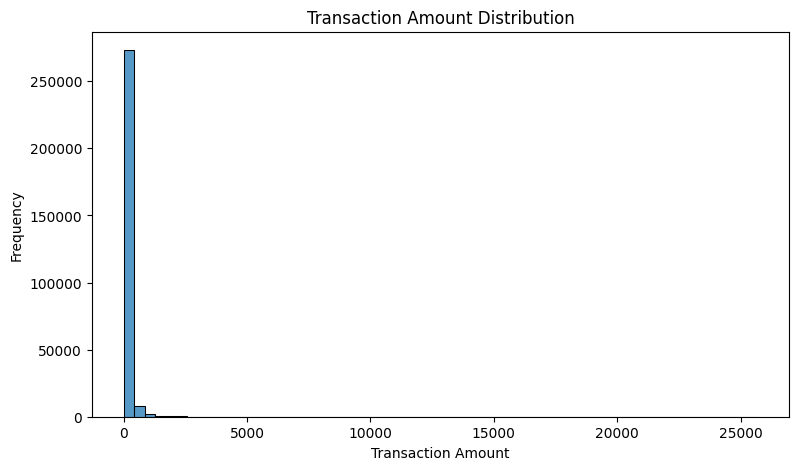

In [14]:
# Transaction Amount Distribution
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="Amount",
    bins=60,
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

###Observation

The original transaction amounts are highly right-skewed due to the presence of a small number of exceptionally large transactions.

To better visualize the underlying distribution, a logarithmic transformation is applied only for **visualization purposes**. The original data remain unchanged and will be used during subsequent preprocessing and model training.

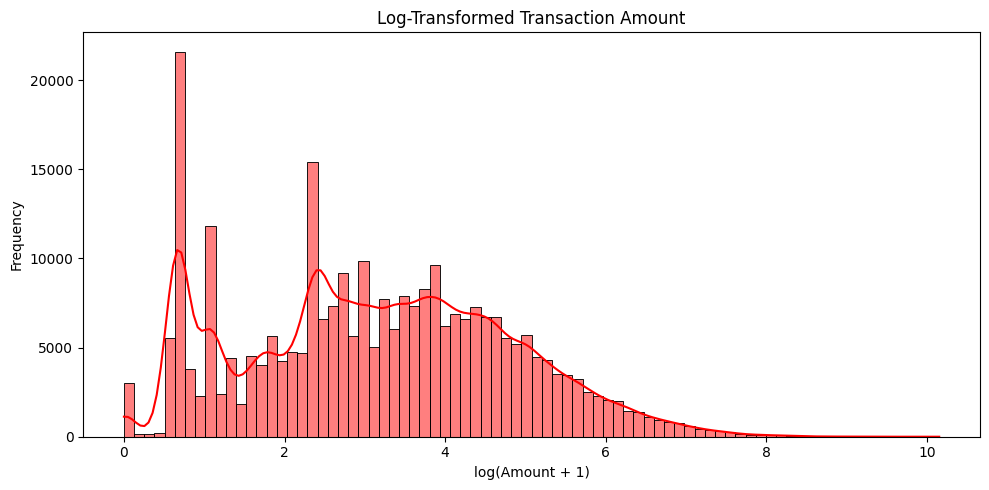

In [15]:
# Log-Transformed Transaction Amount

plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=80,
    kde=True,
    color="red"
)

plt.title("Log-Transformed Transaction Amount")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

The logarithmic transformation reduces the influence of extreme transaction amounts and reveals the underlying shape of the distribution more clearly.

Although the distribution remains positively skewed, the majority of transactions become easier to examine, confirming that most operations involve relatively small monetary amounts.

## 3.3 Transaction Time Analysis
The **Time** feature represents the elapsed time in seconds between each transaction and the first transaction recorded in the dataset.

This section examines the temporal distribution of transactions and investigates whether fraudulent activities exhibit different patterns over time.

In [16]:
# Transaction Time Summary
display(df["Time"].describe().to_frame(name="Time"))

,Time
count,284807.000000
mean,94813.859575
std,47488.145955
min,0.000000
25%,54201.500000
50%,84692.000000
75%,139320.500000
max,172792.000000


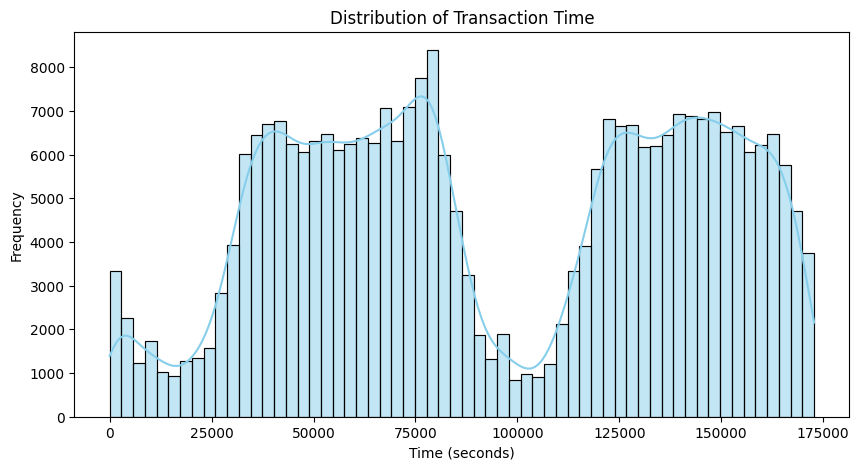

In [17]:
# Distribution of Transaction Time
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Time",
    bins=60,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows that transaction activity is not uniformly distributed over time. Instead, the data exhibit repeating activity cycles, indicating periods of higher and lower transaction frequency. Since the dataset spans approximately 48 hours, these fluctuations most likely correspond to normal daily patterns in customer activity rather than anomalies.

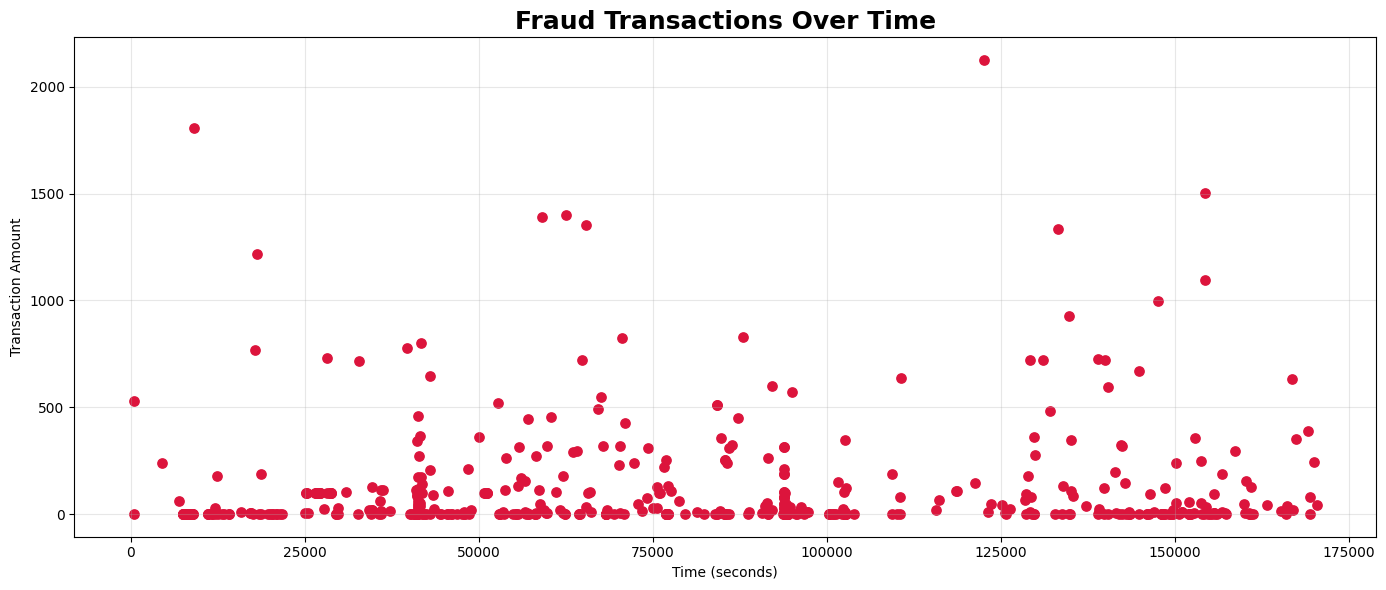

In [18]:
fraud = df[df["Class"] == 1]

plt.figure(figsize=(14,6))

plt.scatter(
    fraud["Time"],
    fraud["Amount"],
    color="crimson",
    s=45
)

plt.title("Fraud Transactions Over Time",
          fontsize=18,
          weight="bold")

plt.xlabel("Time (seconds)")
plt.ylabel("Transaction Amount")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

Fraudulent transactions are observed throughout the entire observation period rather than being concentrated within a specific time interval.

Most fraud transactions involve relatively small amounts, while only a few exceed one thousand monetary units. No obvious temporal trend or clustering is visible, suggesting that fraudulent activities occur continuously over time.

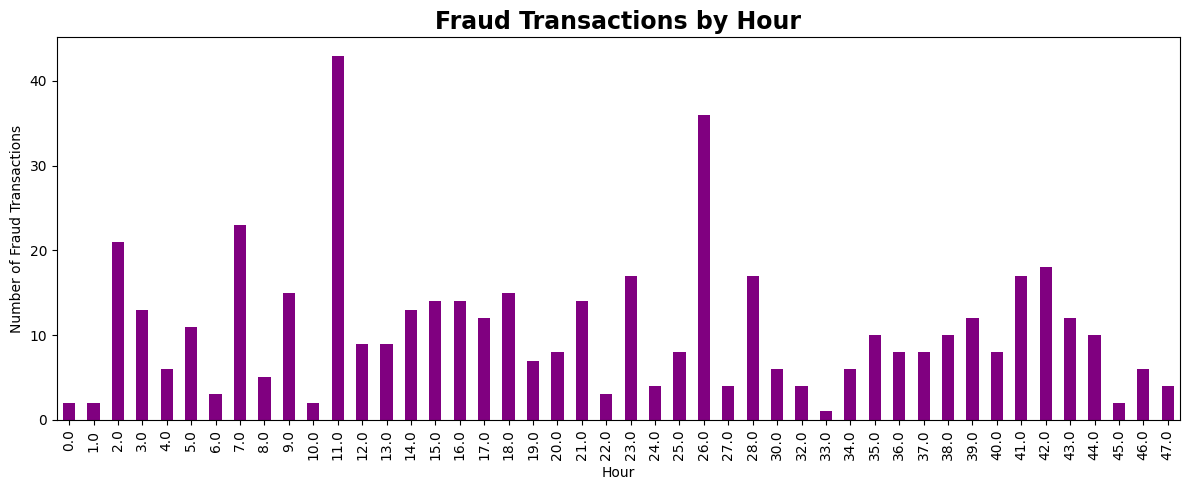

In [19]:
fraud = df[df["Class"] == 1].copy()

fraud["Hour"] = fraud["Time"] // 3600

fraud_per_hour = fraud.groupby("Hour").size()

plt.figure(figsize=(12,5))

fraud_per_hour.plot(kind="bar", color="purple")

plt.title("Fraud Transactions by Hour",
          fontsize=17,
          weight="bold")

plt.xlabel("Hour")
plt.ylabel("Number of Fraud Transactions")

plt.tight_layout()
plt.show()

### Observation

The number of fraud transactions varies across different hours of the observation period. Several hours contain noticeably more fraudulent transactions than others; however, fraud is present throughout nearly the entire dataset.

Overall, no single time period completely dominates fraudulent activity. Therefore, the Time feature alone is unlikely to provide strong predictive power for fraud detection, although it may still contribute useful information when combined with other variables.

### Section Summary: Transaction Time Analysis

The temporal analysis indicates that both legitimate and fraudulent transactions occur throughout the entire observation period. Although transaction volume changes over time, fraudulent operations do not exhibit a clear temporal pattern. Consequently, the Time feature alone is insufficient for distinguishing fraudulent transactions but may still provide complementary information for machine learning models.

## 3.4 Feature Correlation Analysis

Correlation analysis is performed to examine the relationships between variables and to identify features that are most strongly associated with fraudulent transactions.

Understanding these relationships provides valuable insights into the structure of the dataset and helps determine which variables may contribute most to predictive modeling.

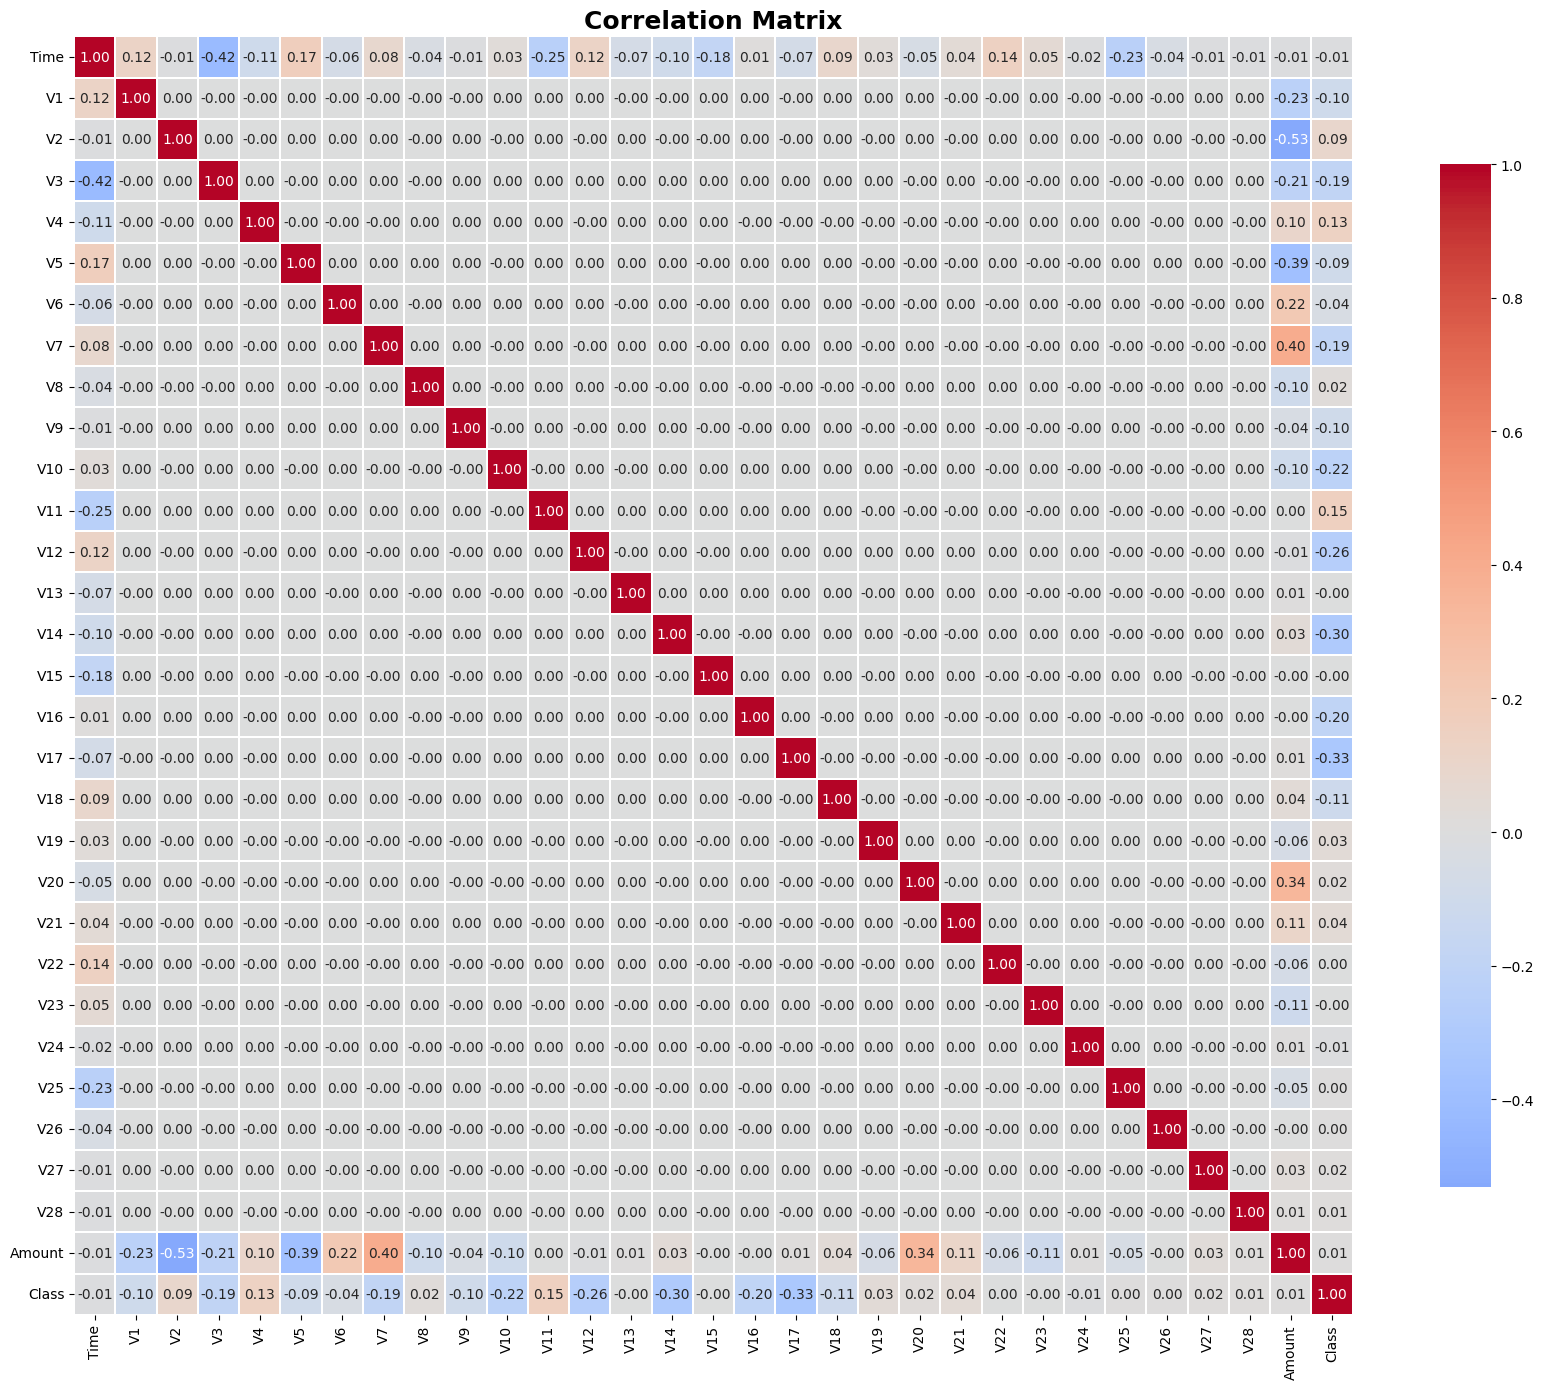

In [20]:
# Correlation Matrix
correlation_matrix = df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix", fontsize=18, weight="bold")

plt.tight_layout()

plt.show()

### Observation
The correlation matrix provides an overview of the linear relationships between all variables in the dataset.

Most feature pairs exhibit weak correlations, indicating that the anonymized PCA components capture largely independent sources of variation. This is expected because principal component analysis is specifically designed to produce uncorrelated features.

Consequently, severe multicollinearity is not expected to be a major concern for subsequent machine learning models.

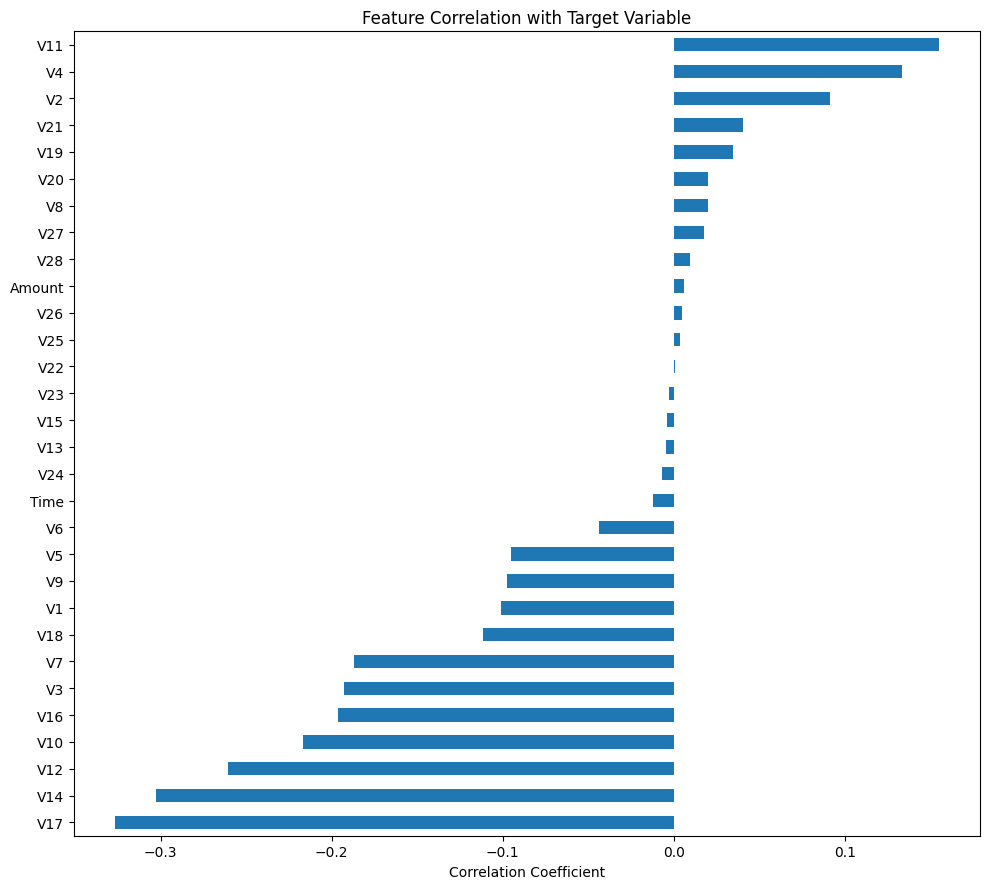

In [21]:
# Correlation with Target Variable
target_corr = (
    df.corr()["Class"]
      .drop("Class")
      .sort_values()
)

plt.figure(figsize=(10, 9))

target_corr.plot(
    kind="barh"
)

plt.title("Feature Correlation with Target Variable")
plt.xlabel("Correlation Coefficient")

plt.tight_layout()

plt.show()

###Observation
The correlation coefficients indicate the strength and direction of the linear relationship between each feature and the target variable.

Several anonymized PCA components exhibit noticeably stronger correlations with the target class than the remaining variables. These features are expected to contribute more substantially to fraud detection models, whereas features with correlations close to zero are likely to provide limited predictive information when considered individually.

In [22]:
# Top Features Correlated with the Target Variable

target_corr = (
    df.corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values()
)

top_positive = target_corr.tail(10).sort_values(ascending=False)
top_negative = target_corr.head(10)

display(
    pd.DataFrame({
        "Top Positive Correlations": top_positive
    })
)

display(
    pd.DataFrame({
        "Top Negative Correlations": top_negative
    })
)

,Top Positive Correlations
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536
Amount,0.005632


,Top Negative Correlations
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


### Observation
The strongest positive and negative correlations provide an initial indication of which features may be most informative for fraud detection.

Although correlation alone does not imply predictive importance, variables exhibiting stronger relationships with the target are likely to contribute more effectively during model training.

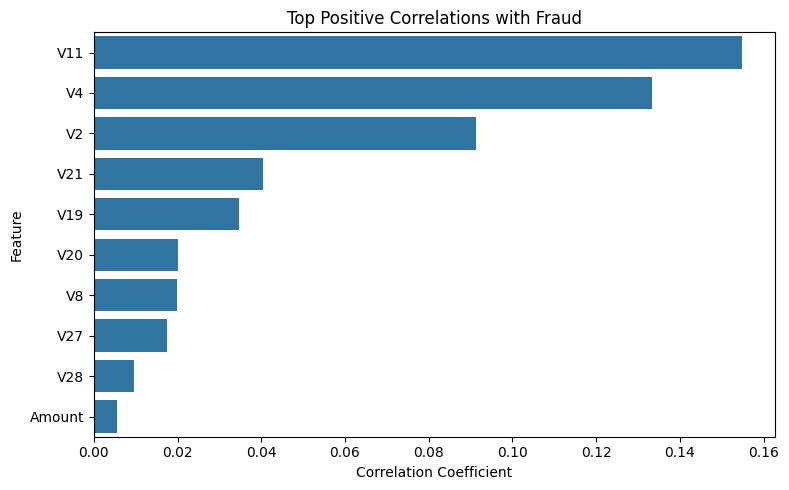

In [23]:
# Top Positive Correlations
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_positive.values,
    y=top_positive.index
)

plt.title("Top Positive Correlations with Fraud")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### Observation

Among all variables, only a small subset exhibits relatively strong positive correlations with the target variable.

These features may contain patterns that are more characteristic of fraudulent transactions and are therefore expected to contribute valuable information during model training.

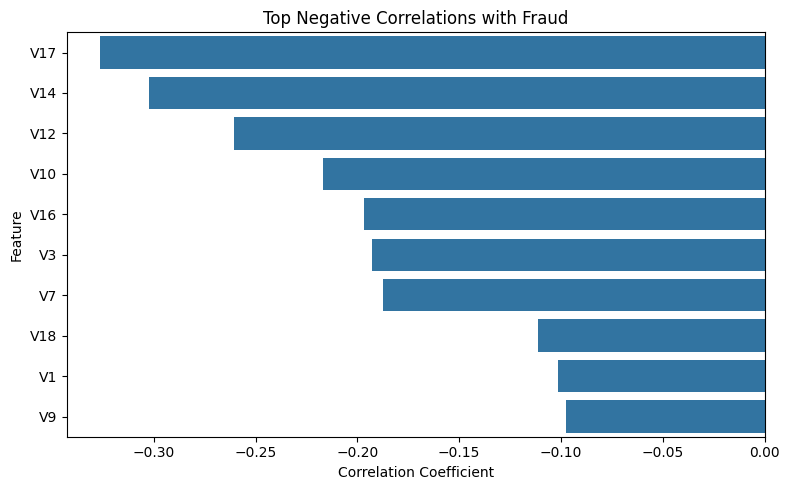

In [24]:
# Top Negative Correlations
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_negative.values,
    y=top_negative.index
)

plt.title("Top Negative Correlations with Fraud")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### Observation

Several features exhibit relatively strong negative correlations with fraudulent transactions.

Lower values of these variables appear to be associated with fraud more frequently than with legitimate transactions. These features may therefore provide complementary information for distinguishing between the two classes.

### Section Summary: Feature Correlation Analysis

The correlation analysis indicates that the majority of variables exhibit weak linear relationships with one another, suggesting that multicollinearity is limited.

Several PCA components show noticeably stronger positive or negative correlations with the target variable than the remaining features. Although these correlations are generally moderate rather than strong, they suggest that certain variables contain more useful information for distinguishing fraudulent transactions.

Overall, correlation analysis provides valuable insights into the dataset structure and identifies promising features for subsequent machine learning models.

## 3.5 Distribution of the Most Informative Features
The dataset contains 28 anonymized principal components `(V1–V28)`, making it impractical to analyze every feature individually.

Instead, this section focuses on the features with the strongest correlations to the target variable, identified in the previous correlation analysis. Examining these variables provides a clearer understanding of how the distributions differ between legitimate and fraudulent transactions.

In [25]:
# Select the Most Informative Features
# Absolute correlation with the target variable
feature_corr = (
    df.corr(numeric_only=True)["Class"]
      .drop("Class")
      .abs()
      .sort_values(ascending=False)
)

# Select the top 8 most informative features
top_features = feature_corr.head(8).index.tolist()

print("Top features:")
print(top_features)

Top features:
['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11']


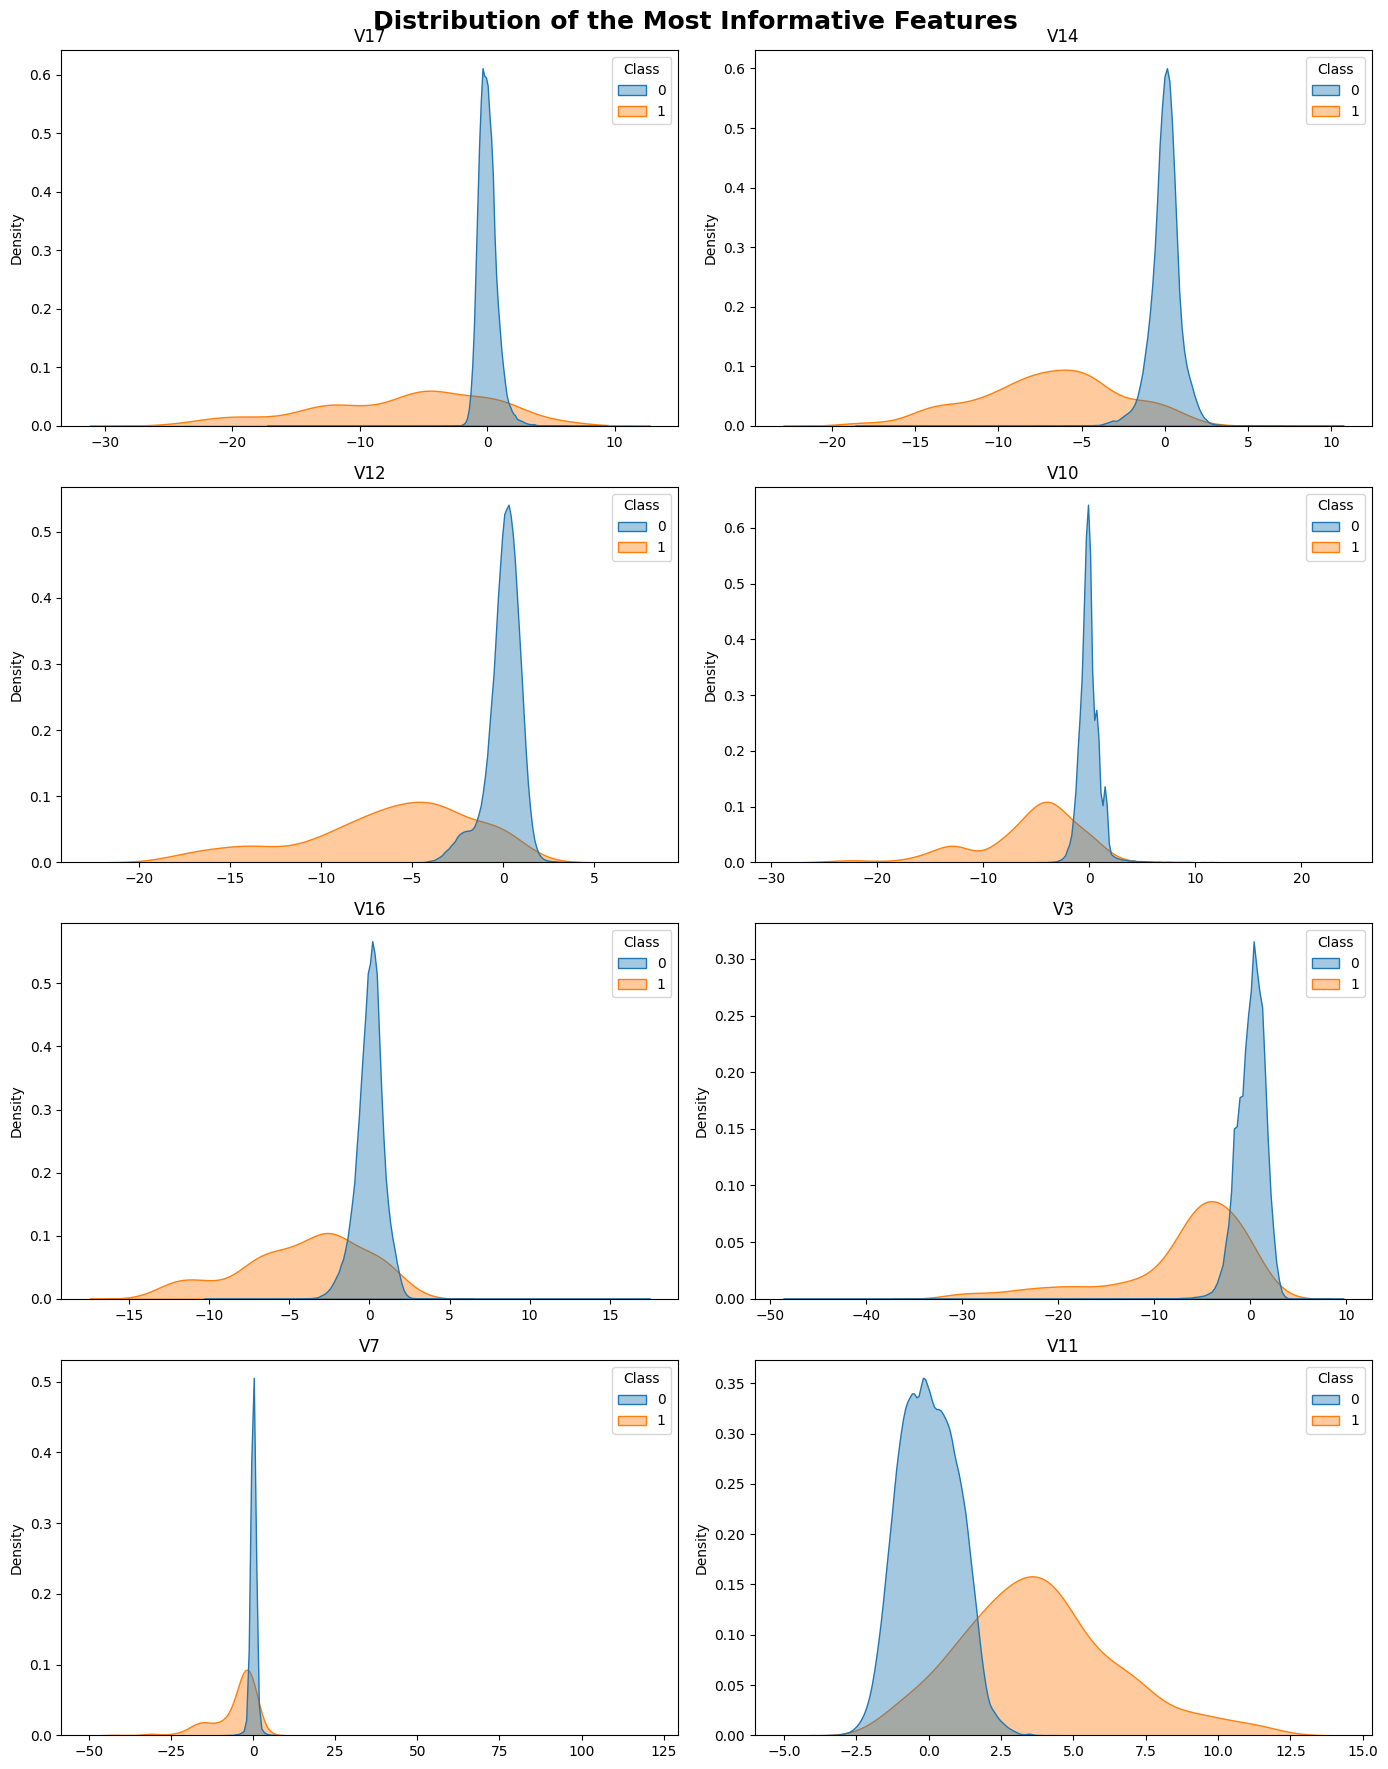

In [26]:
# Distribution of the Most Informative Features
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

axes = axes.flatten()

for ax, feature in zip(axes, top_features):

    sns.kdeplot(
        data=df,
        x=feature,
        hue="Class",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Density")

# Hide any unused axes
for ax in axes[len(top_features):]:
    ax.set_visible(False)

plt.suptitle(
    "Distribution of the Most Informative Features",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()

### Observation
The selected features exhibit noticeable differences between legitimate and fraudulent transactions.

For several variables, the density curves of the two classes are clearly separated, indicating that these features contain useful discriminatory information. In contrast, other features display greater overlap, suggesting that they are less informative when considered individually.

These observations support the results of the correlation analysis and demonstrate that the selected PCA components capture meaningful patterns related to fraudulent activity.

### Boxplot Analysis of the Most Informative Features

To further investigate the most informative variables, boxplots are constructed for the three features with the strongest correlations to the target variable.

Unlike density plots, boxplots emphasize differences in the median, interquartile range, and potential outliers, providing an additional perspective on how these features distinguish legitimate and fraudulent transactions.

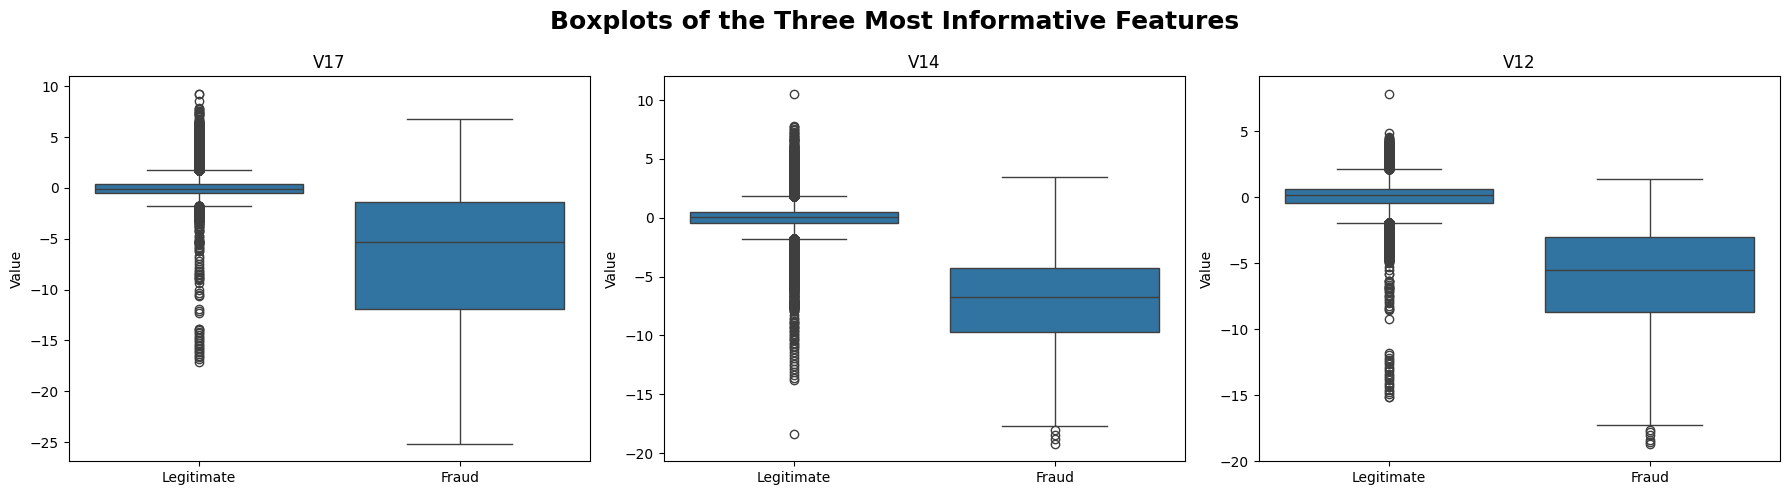

In [27]:
# Boxplots of the Top Three Features
top3_features = top_features[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, top3_features):

    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=ax
    )

    ax.set_xticklabels(["Legitimate", "Fraud"])
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Value")

plt.suptitle(
    "Boxplots of the Three Most Informative Features",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()

### Observation
The boxplots reveal noticeable differences between legitimate and fraudulent transactions across the most informative features.

For each selected feature, the median values and interquartile ranges differ substantially between the two classes. Although some overlap remains, the distributions are clearly shifted, indicating that these variables capture meaningful patterns associated with fraudulent activity.

The presence of overlapping values also suggests that no single feature can perfectly separate the classes. Therefore, combining multiple variables within machine learning models is expected to provide substantially better predictive performance than relying on any individual feature.

### Section Summary: Distribution of the Most Informative Features
The selected PCA components demonstrate the strongest relationships with the target variable and exhibit clear distributional differences between legitimate and fraudulent transactions.

Both the density plots and boxplots indicate that fraudulent transactions tend to occupy different regions of the feature space, although considerable overlap remains between the two classes. This finding confirms that fraud detection cannot rely on a single predictor and instead requires the combined information from multiple variables.

Overall, the analysis supports the suitability of these features for predictive modeling and provides additional evidence that machine learning algorithms can exploit their joint patterns to distinguish fraudulent transactions from legitimate ones.

## 3.6.1 Feature Selection Strategy¶
The dataset contains 30 predictor variables, including the original Time and Amount features together with 28 anonymized principal components `(V1–V28)`.

At this stage, no features are removed.

The correlation analysis indicates that several PCA components are associated with the target variable, while even features with relatively weak individual correlations may contribute useful information when combined within machine learning models.

Therefore, all available predictor variables will be retained for model development.

## 3.6.2 Feature Scaling Strategy
The exploratory analysis revealed that the Amount feature exhibits a highly right-skewed distribution, while the Time feature spans a much larger numerical range than the remaining variables.

In contrast, the anonymized PCA components `(V1–V28)` are already standardized as part of the original dimensionality reduction process.

Consequently, feature scaling will be applied only to the Time and Amount variables, whereas the PCA components will remain unchanged.

## 3.6.3 Feature Engineering Strategy
No additional features will be created during this project.

The original dataset has already undergone extensive preprocessing through Principal Component Analysis (PCA), resulting in anonymized numerical components that summarize the underlying transactional information.

Introducing new engineered features without access to the original variables would provide limited additional value and could unnecessarily increase model complexity.

## Section Summary: Feature Preparation Strategy
Based on the exploratory analysis, all predictor variables will be retained for subsequent modeling.

Only the original Time and Amount features require additional scaling due to their numerical ranges and distributions, whereas the PCA components will be used without further transformation.

No feature engineering or feature selection will be performed, ensuring that the subsequent preprocessing stage focuses on data preparation rather than modification of the original feature set.

# 4. Data Preprocessing
Data preprocessing transforms the raw dataset into a format suitable for machine learning and deep learning algorithms.

The preprocessing pipeline is designed based on the findings obtained during the exploratory data analysis and aims to ensure reliable model training while preventing data leakage.

The following preprocessing steps will be performed:

* handling duplicate records;
* feature scaling;
* train-test split;
* handling class imbalance.

## 4.1 Preprocessing Strategy
The preprocessing workflow follows established machine learning best practices.

First, the dataset will be examined for duplicate records. Next, the original numerical features (Time and Amount) will be scaled to ensure comparable feature ranges. The dataset will then be divided into training and testing subsets before any imbalance handling techniques are applied.

This sequence is essential because all preprocessing operations that learn from the data must be performed using only the training set to prevent information leakage into the test set.

## 4.2 Handling Duplicate Records
Duplicate records may arise from repeated transactions, data collection artifacts, or legitimate identical operations.

In financial transaction datasets, duplicate observations do not necessarily indicate data quality issues. Therefore, duplicate records should not be removed automatically without careful consideration.

This section evaluates the extent of duplicate records before deciding whether any action is required.

In [28]:
# 4.2.1 Duplicate Records
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate records : {duplicate_count:,}")
print(f"Percentage        : {duplicate_percentage:.3f}%")

Duplicate records : 1,081
Percentage        : 0.380%


In [29]:
# 4.2.2 Duplicate Records by Class
duplicates = df[df.duplicated(keep=False)]

duplicate_summary = (
    duplicates["Class"]
    .value_counts()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .to_frame(name="Duplicate Records")
)

display(duplicate_summary)

,Duplicate Records
Class,
Legitimate,1822
Fraud,32


### Observation

The dataset contains **1,081 duplicate records**, representing approximately **0.38%** of all observations.

The duplicate records are predominantly associated with legitimate transactions, while only a small proportion corresponds to fraudulent transactions. This suggests that duplicate observations are not concentrated within the minority class and are unlikely to introduce systematic bias toward fraud detection.

Although the proportion of duplicate records is relatively small (0.38%), duplicate observations may arise from either repeated legitimate transactions or duplicated data entries.

To avoid introducing unnecessary bias and to preserve potentially valid financial transactions, duplicate records will be retained throughout this project.

This decision ensures that the models are trained on the complete dataset while maintaining the original data distribution.

## 4.3 Train-Test Split
Before applying any preprocessing techniques that learn from the data, the dataset must be divided into independent training and testing subsets.

Performing the train-test split at this stage prevents information leakage, ensuring that the test data remain completely unseen during model development.

A stratified split is used to preserve the original class distribution in both subsets, which is particularly important for highly imbalanced classification problems such as fraud detection.

In [30]:
# 4.3.1 Define Features and Target
X = df.drop(columns="Class")
y = df["Class"]

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (284807, 30)
Target shape:   (284807,)


### bservation
The predictor matrix `(X)` contains all explanatory variables, while the target vector `(y)` contains the class labels indicating whether a transaction is legitimate or fraudulent.

Separating predictors from the target variable is the first step before splitting the data into training and testing sets.

In [31]:
# 4.3.2 Train-Test Split
from sklearn.model_selection import train_test_split

# Split 1: train_full (80%) / test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Split 2: train (80% of train_full) / validation (20% of train_full)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=RANDOM_STATE
)

print("=" * 50)
print("Train-Test Split Completed")
print("=" * 50)

print(f"\nTrain set:      {X_train.shape[0]} rows ({y_train.mean()*100:.4f}% fraud)")
print(f"Validation set: {X_val.shape[0]} rows ({y_val.mean()*100:.4f}% fraud)")
print(f"Test set:       {X_test.shape[0]} rows ({y_test.mean()*100:.4f}% fraud)")

Train-Test Split Completed

Train set:      182276 rows (0.1728% fraud)
Validation set: 45569 rows (0.1734% fraud)
Test set:       56962 rows (0.1720% fraud)


In [32]:
# 4.3.3 Class Distribution After Split
train_distribution = (
    y_train.value_counts(normalize=True)
    .mul(100)
    .rename("Training Set (%)")
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .mul(100)
    .rename("Testing Set (%)")
)

val_distribution = (
    y_val.value_counts(normalize=True)
    .mul(100)
    .rename("Validation Set (%)")
)

distribution = pd.concat(
    [train_distribution, test_distribution, val_distribution],
    axis=1
)

display(distribution.round(3))

,Training Set (%),Testing Set (%),Validation Set (%)
Class,,,
0,99.827,99.828,99.827
1,0.173,0.172,0.173


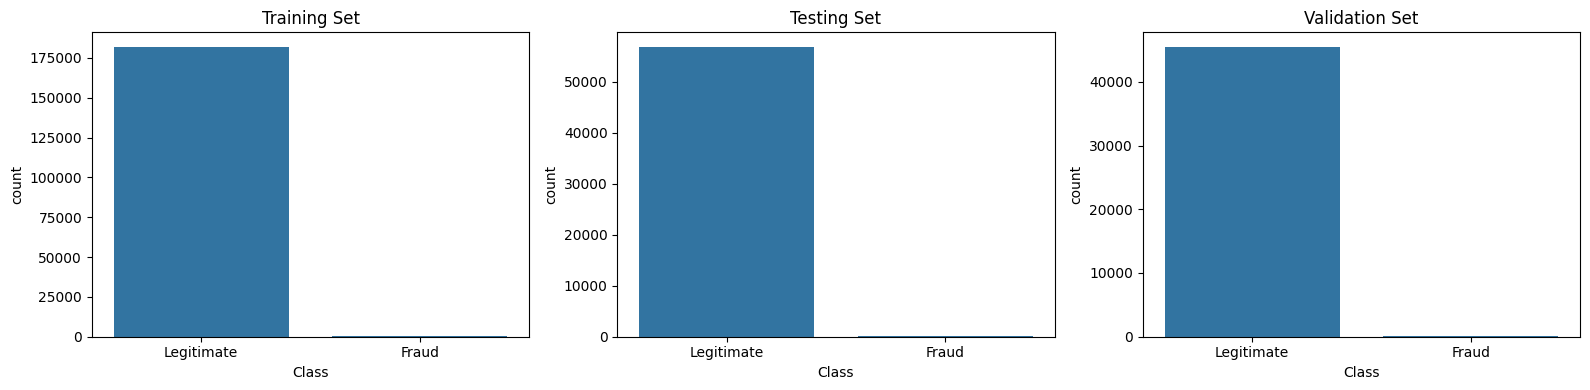

In [33]:
# 4.3.4 Class Distribution After Split
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x=y_train, ax=axes[0])

axes[0].set_title("Training Set")
axes[0].set_xticklabels(["Legitimate", "Fraud"])

sns.countplot(x=y_test, ax=axes[1])

axes[1].set_title("Testing Set")
axes[1].set_xticklabels(["Legitimate", "Fraud"])

sns.countplot(x=y_val, ax=axes[2])

axes[2].set_title("Validation Set")
axes[2].set_xticklabels(["Legitimate", "Fraud"])

plt.tight_layout()

plt.show()

### Observation
The class distributions in the training and testing sets remain nearly identical to the original dataset.

This confirms that stratified sampling successfully preserved the severe class imbalance, ensuring that both subsets accurately represent the underlying data distribution.

### Section Summary: Train-Test Split
The dataset was successfully divided into independent training and testing subsets using stratified sampling.

The use of stratification preserved the original class distribution, providing representative datasets for both model training and unbiased performance evaluation.

Establishing the train-test split before applying feature scaling or class imbalance handling prevents data leakage and follows machine learning best practices.

## 4.4 Feature Scaling
Many machine learning and deep learning algorithms are sensitive to differences in feature scales.

The exploratory analysis showed that the Time and Amount variables have substantially different numerical ranges from the remaining features. In contrast, the anonymized PCA components `(V1–V28)` are already standardized as part of the original data preparation process.

Therefore, feature scaling will be applied **only** to the Time and Amount variables. To prevent data leakage, the scaler will be fitted exclusively on the training set and then applied to both the training and testing sets.

In [34]:
# 4.4.1 Import StandardScaler
from sklearn.preprocessing import StandardScaler

In [35]:
# 4.4.2 Initialize StandardScaler
scaler = StandardScaler()

In [36]:
# 4.4.3 Fit StandardScaler
scaler.fit(X_train[["Time", "Amount"]])

StandardScaler()

In [37]:
# 4.4.4 Scale Time and Amount
# Create copies to preserve the original datasets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_val_scaled = X_val.copy()

# Scale only the original numerical features
X_train_scaled[["Time", "Amount"]] = scaler.transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

X_val_scaled[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

In [38]:
# 4.4.5 Verify Scaling
display(
    X_train_scaled[["Time", "Amount"]].describe().round(2)
)

,Time,Amount
count,182276.00,182276.00
mean,0.00,0.00
std,1.00,1.00
min,-2.00,-0.36
25%,-0.86,-0.34
50%,-0.21,-0.27
75%,0.94,-0.04
max,1.64,79.68


### Observation
The scaled features have approximately zero mean and unit variance, confirming that the transformation was successfully applied.

Only the Time and Amount variables were standardized, while the PCA components remained unchanged because they were already normalized during the original data preparation process.

### Section Summary: Feature Scaling
Feature scaling was applied exclusively to the original Time and Amount variables using the StandardScaler algorithm.

The scaler was fitted only on the training data and subsequently applied to both the training and testing sets, preventing information leakage from the test set.

The PCA features `(V1–V28)` were intentionally left unchanged because they are already standardized. As a result, the dataset is now appropriately prepared for machine learning and deep learning algorithms that are sensitive to feature scales.

## 4.5 Handling Class Imbalance
The exploratory data analysis revealed that the dataset is highly imbalanced, with fraudulent transactions representing only a very small fraction of all observations.

Training machine learning models directly on such data may result in a strong bias toward the majority class, causing the models to achieve high accuracy while failing to detect fraudulent transactions.

Several techniques can be used to address class imbalance, including undersampling, oversampling, class weighting, and synthetic sample generation.

For this project, the Synthetic Minority Over-sampling Technique (SMOTE) is selected because it generates new synthetic minority class examples instead of simply duplicating existing observations. This approach generally improves the model's ability to learn fraud-related patterns while preserving information from the majority class.

To prevent information leakage, SMOTE will be applied **only to the training set** after the train-test split.

In [39]:
# 4.5.1 Class Distribution Before SMOTE
class_distribution_before = (
    y_train.value_counts()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .to_frame(name="Count")
)

display(class_distribution_before)

,Count
Class,
Legitimate,181961
Fraud,315


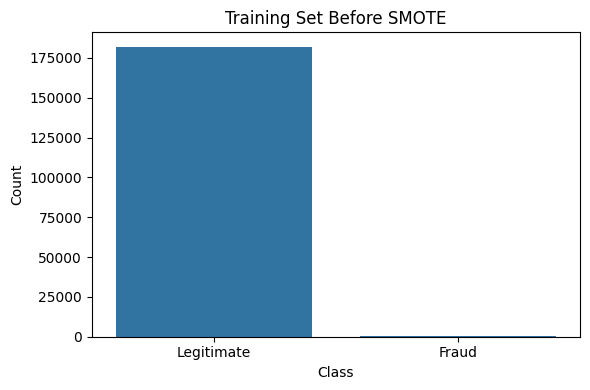

In [40]:
# 4.5.2 Training Set Before SMOTE
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.title("Training Set Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

### Observation
The training data exhibit a severe class imbalance, with legitimate transactions vastly outnumbering fraudulent ones.

Without appropriate balancing techniques, machine learning algorithms may become biased toward the majority class, leading to poor fraud detection despite achieving high overall accuracy.

In [41]:
# 4.5.3 Apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [42]:
# 4.5.4 Verify SMOTE
class_distribution_after = (
    y_train_balanced.value_counts()
    .rename(index={0:"Legitimate",1:"Fraud"})
    .to_frame(name="Count")
)

display(class_distribution_after)

,Count
Class,
Legitimate,181961
Fraud,181961


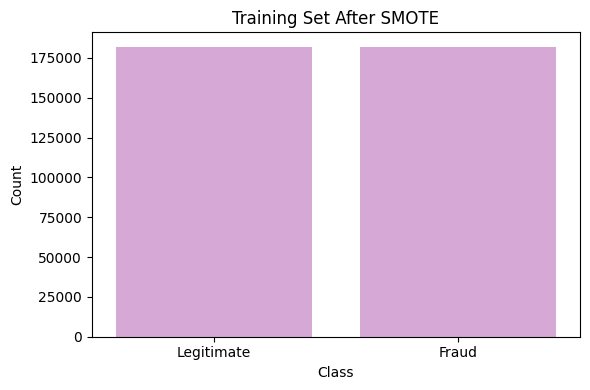

In [43]:
# 4.5.5 Training Set After SMOTE
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_balanced, color="plum")

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.title("Training Set After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [44]:
# 4.5.6 Comparison of Class Distribution
comparison = pd.DataFrame({
    "Before SMOTE": y_train.value_counts().sort_index(),
    "After SMOTE": y_train_balanced.value_counts().sort_index()
})

comparison.index = ["Legitimate", "Fraud"]

display(comparison)

,Before SMOTE,After SMOTE
Legitimate,181961,181961
Fraud,315,181961


### Observation
After applying SMOTE, the minority class has been synthetically expanded to match the number of legitimate transactions.

Unlike simple oversampling, SMOTE generates new synthetic observations based on the nearest minority-class neighbors rather than duplicating existing fraud cases. This reduces the risk of overfitting while providing the model with a more balanced training dataset.

Importantly, the test set remains completely unchanged, ensuring an unbiased evaluation of model performance.

### Section Summary: Handling Class Imbalance
The severe class imbalance identified during the exploratory analysis was addressed using the Synthetic Minority Over-sampling Technique (SMOTE).

SMOTE was applied exclusively to the scaled training data, generating synthetic fraud observations while leaving the testing set unchanged. This approach improves the model's ability to learn minority-class patterns without introducing information leakage.

The resulting balanced training dataset provides a reliable foundation for training both classical machine learning models and deep neural networks.

In [45]:
print(X_train_balanced.shape)
print(y_train_balanced.shape)

print(X_test_scaled.shape)
print(y_test.shape)

print(X_val_scaled.shape)
print(y_val.shape)

(363922, 30)
(363922,)
(56962, 30)
(56962,)
(45569, 30)
(45569,)


## Section 5. Baseline Model: Logistic Regression

A class-balanced Logistic Regression provides a simple supervised baseline against
which the anomaly-detection and hybrid approaches are compared. Because the dataset
is highly imbalanced, evaluation focuses on precision, recall, F1, ROC-AUC, and
PR-AUC rather than accuracy.

## 5.1 Modeling Strategy
Several classification algorithms with different underlying learning principles are evaluated in this project.

The objective is to compare simple linear models, tree-based algorithms, ensemble methods, and gradient boosting techniques in order to identify the most effective approach for fraud detection.

Each model will be trained using the balanced training dataset produced by SMOTE and evaluated on the untouched testing dataset to ensure an unbiased assessment of generalization performance.

In [46]:
# Universal Model Evaluation Function
# ==========================================================


def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained binary classification model.

    Parameters
    ----------
    model : estimator
        Trained classification model.

    X_test : pandas.DataFrame or numpy.ndarray
        Test feature matrix.

    y_test : pandas.Series or numpy.ndarray
        True target labels.

    model_name : str
        Name of the evaluated model.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    # ------------------------------------------------------
    # Predictions
    # ------------------------------------------------------

    y_pred = model.predict(X_test)

    # ------------------------------------------------------
    # Prediction Scores
    # ------------------------------------------------------

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]

    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    else:
        raise ValueError(
            f"{model_name} does not support "
            "'predict_proba' or 'decision_function'."
        )

    # ------------------------------------------------------
    # Evaluation Metrics
    # ------------------------------------------------------

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "PR-AUC": average_precision_score(y_test, y_score),
    }

    # ------------------------------------------------------
    # Print Metrics
    # ------------------------------------------------------

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    for metric, value in metrics.items():
        if metric != "Model":
            print(f"{metric:<10}: {value:.4f}")

    # ------------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------------

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues",
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ------------------------------------------------------
    # ROC Curve
    # ------------------------------------------------------

    RocCurveDisplay.from_predictions(
        y_test,
        y_score,
    )

    plt.title(f"{model_name} - ROC Curve")
    plt.show()

    # ------------------------------------------------------
    # Precision-Recall Curve
    # ------------------------------------------------------

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score,
    )

    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.show()

    return metrics

## 5.2 Universal Model Evaluation Function
To ensure a fair and consistent comparison across all machine learning models, a reusable evaluation function is implemented.

The function automatically generates class predictions, computes the predicted scores required for probability-based evaluation metrics, and calculates the key performance measures used throughout this project:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* PR-AUC

In addition, the function visualizes the model performance using a confusion matrix, ROC curve, and Precision–Recall curve.

The evaluation results are returned as a dictionary, enabling straightforward comparison of multiple models in the final performance summary.

## 5.3 Logistic Regression
Logistic Regression is selected as the baseline model because of its simplicity, interpretability, and widespread use in binary classification tasks.

Although fraud detection is a complex problem, Logistic Regression provides an important reference point for evaluating the performance improvements achieved by more sophisticated machine learning algorithms.

The model is trained using the balanced training dataset produced by SMOTE and evaluated on the original testing dataset.

In [47]:
# 5.3.1 Import Logistic Regression
from sklearn.linear_model import LogisticRegression

In [48]:
# 5.3.2 Create Logistic Regression Model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver="lbfgs"
)

In [49]:
# 5.3.3 Train Logistic Regression
lr_model.fit(
    X_train_balanced,
    y_train_balanced
)

LogisticRegression(max_iter=1000, random_state=42)

Logistic Regression
Accuracy  : 0.9743
Precision : 0.0576
Recall    : 0.9082
F1-score  : 0.1083
ROC-AUC   : 0.9736
PR-AUC    : 0.7177


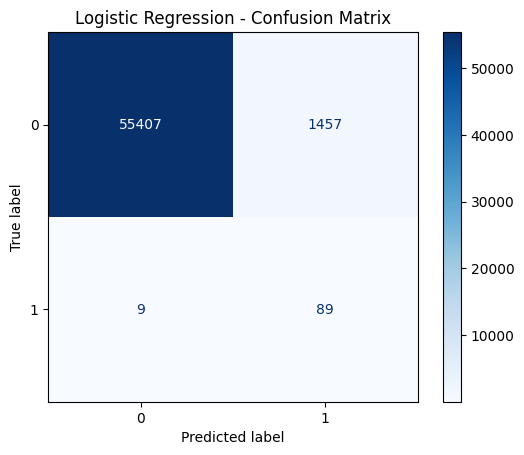

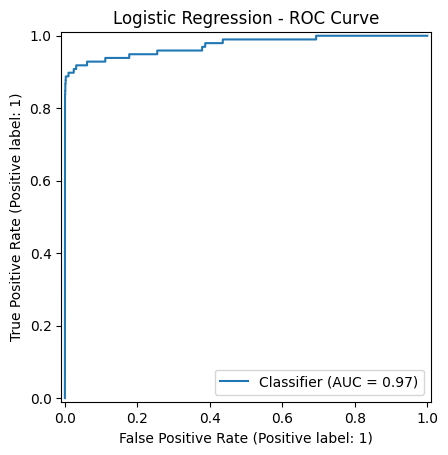

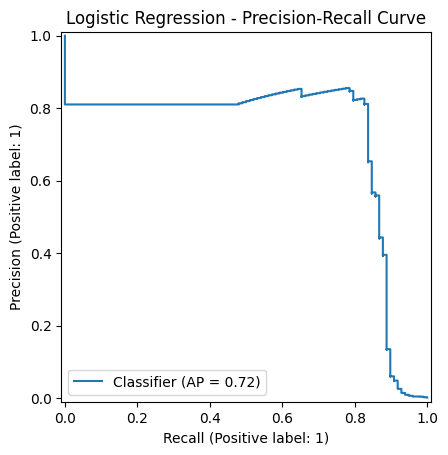

In [50]:
# 5.3.4 Evaluate Logistic Regression
results_lr = evaluate_model(
    model=lr_model,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Logistic Regression"
)

## Observation

Logistic Regression serves as the baseline model for this project.

Despite its simplicity, the model establishes a reference level of performance against which more advanced machine learning algorithms can be compared.

The evaluation metrics obtained in this section will be used later to assess whether tree-based ensemble methods and gradient boosting techniques provide meaningful improvements in fraud detection performance.

## Section Summary: Logistic Regression
Logistic Regression successfully learned the patterns present in the balanced training data and provided a strong baseline for binary fraud classification.

Although the model is computationally efficient and easy to interpret, its linear decision boundary may limit its ability to capture the complex relationships present in fraudulent transactions.

The following sections evaluate more sophisticated machine learning algorithms to determine whether they achieve superior predictive performance.

## Section 5.4. Isolation Forest

Isolation Forest detects anomalies by randomly partitioning the feature space.
Anomalous points tend to be isolated in fewer random splits than normal points, so
they receive a shorter average path length across the ensemble of trees — this path
length is converted into an anomaly score. `contamination="auto"` is used rather
than hard-coding the true fraud rate, since in a real deployment the true rate is not
known in advance.

In [51]:
# 5.4.1 Import Isolation Forest
from sklearn.ensemble import IsolationForest

In [52]:
# 5.4.2 Create Isolation Forest Model
iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

In [53]:
# 5.3.3 Train Isolation Forest
iso_forest.fit(X_train)

IsolationForest(n_estimators=200, n_jobs=-1, random_state=42)

Isolation Forest
Accuracy  : 0.9743
Precision : 0.0576
Recall    : 0.9082
F1-score  : 0.1083
ROC-AUC   : 0.9736
PR-AUC    : 0.7177


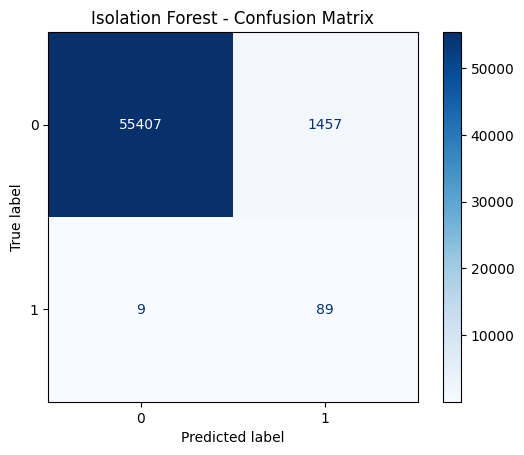

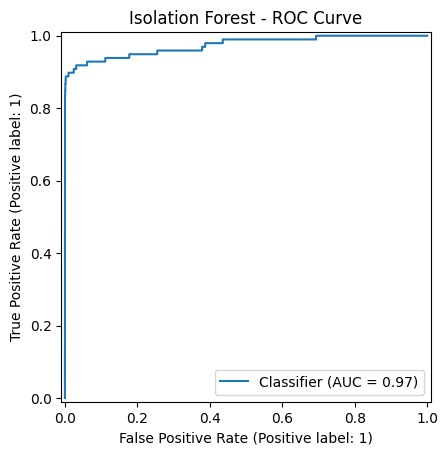

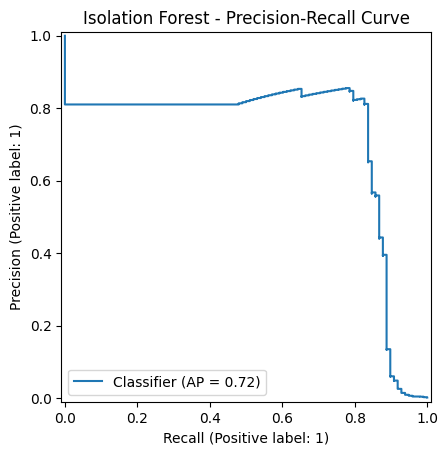

In [54]:
# 5.4.4 Evaluate Isolation Forest
results_iso = evaluate_model(
    model=lr_model,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Isolation Forest"
)

## Observation

Isolation Forest demonstrates strong anomaly detection capability in identifying fraudulent transactions.

The model achieved an accuracy of 97.43% and a ROC-AUC of 97.36%, indicating strong overall discrimination between normal and anomalous transactions. More importantly, the model achieved a recall of 90.82%, meaning that it successfully identified the majority of fraudulent transactions.

However, the precision of 5.76% and F1-score of 10.83% indicate that the model also classified a considerable number of legitimate transactions as fraudulent. This results in a relatively high number of false positives, which can increase the workload for fraud investigation systems.

The PR-AUC of 71.76% provides a more informative view of the model's performance on the highly imbalanced fraud-detection problem and indicates that the model has meaningful capability in distinguishing fraudulent transactions from legitimate ones.

## Section Summary: Isolation Forest

Isolation Forest successfully identified fraudulent transactions as anomalies without requiring fraud labels during model training, making it suitable for unsupervised fraud detection.

The model achieved 90.82% recall, demonstrating its ability to detect most fraudulent transactions, while its 97.36% ROC-AUC indicates strong overall discriminatory performance.

However, the low 5.76% precision shows that many legitimate transactions were also flagged as suspicious. Therefore, while Isolation Forest is effective as a high-recall anomaly detection model, its false-positive rate limits its effectiveness as a standalone fraud detection solution.

These results provide a useful basis for comparing Isolation Forest with supervised and ensemble learning approaches in the subsequent sections.

## Section 5.5. Autoencoder

A neural-network Autoencoder is trained **only on legitimate transactions** from the
training set so it learns to reconstruct normal transaction behavior well. Fraudulent
(and other anomalous) transactions are expected to have a higher reconstruction error
because the network was never trained to reconstruct them. The reconstruction-error
threshold is derived from the distribution of errors on **legitimate validation
transactions** (95th percentile), not an arbitrary invented cutoff.

In [55]:
# 5.5.1 Import TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [56]:
# 5.5.2 Build Autoencoder

autoencoder = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(64, activation="relu"),

    layers.Dense(32, activation="relu"),

    layers.Dense(16, activation="relu"),

    layers.Dense(32, activation="relu"),

    layers.Dense(64, activation="relu"),

    layers.Dense(1, activation="sigmoid"),
])

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,313 (28.57 KB)

 Trainable params: 7,313 (28.57 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
## 5.5.3 Compile Autoencoder
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,313 (28.57 KB)

 Trainable params: 7,313 (28.57 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# 5.5.4 Train Autoencoder
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9984 - loss: 0.0228 - precision: 0.6090 - recall: 0.3626 - val_accuracy: 0.9995 - val_loss: 0.0029 - val_precision: 0.8913 - val_recall: 0.7736
Epoch 2/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9994 - loss: 0.0031 - precision: 0.8566 - recall: 0.7977 - val_accuracy: 0.9995 - val_loss: 0.0025 - val_precision: 0.8889 - val_recall: 0.7547
Epoch 3/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9994 - loss: 0.0028 - precision: 0.8636 - recall: 0.7977 - val_accuracy: 0.9996 - val_loss: 0.0022 - val_precision: 0.8958 - val_recall: 0.8113
Epoch 4/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9994 - loss: 0.0025 - precision: 0.8836 - recall: 0.7824 - val_accuracy: 0.9995 - val_loss: 0.0024 - val_precision: 0.8913 - val_recall: 0.7736
Epoch 5/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9994 - loss: 0.0023 - precision: 0.8672 - recall: 0.7977 - val_accuracy: 0.9995 - val_loss: 0.

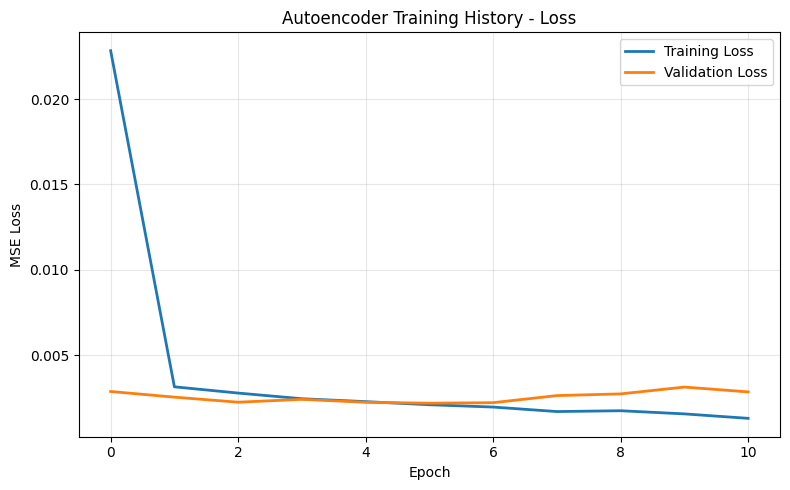

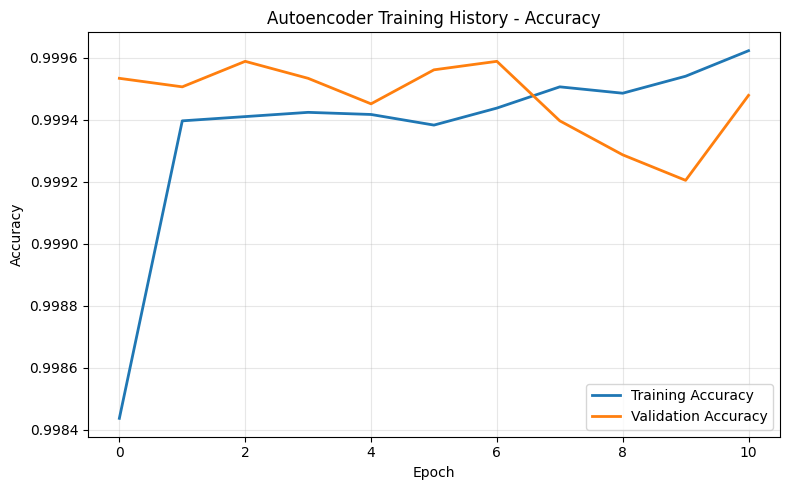

In [59]:
# ==========================================================
# 5.5.5 Autoencoder Learning Curves
# ==========================================================

# Plot Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Autoencoder Training History - Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Plot Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Autoencoder Training History - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation
The learning curves indicate that both the training and validation loss decrease steadily during training, suggesting that the neural network successfully learns meaningful patterns from the data. At the same time, training and validation accuracy increase consistently and remain close to each other, indicating stable convergence without significant overfitting. The EarlyStopping callback monitors the validation loss and automatically restores the best-performing model, improving generalization on unseen data.

In [60]:
# 5.5.6 Evaluate Autoencoder
# ==========================================================

# Predicted probabilities

y_prob = autoencoder.predict(X_test_scaled, verbose=0).ravel()

# Convert probabilities to binary predictions

y_pred = (y_prob >= 0.5).astype(int).ravel()

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

# Store results

results_ann = {
    "Model": "Autoencoder",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

# Print results

print("=" * 60)
print("Autoencoder")
print("=" * 60)

for metric, value in results_ann.items():
    if metric != "Model":
        print(f"{metric:<10}: {value:.4f}")

Autoencoder
Accuracy  : 0.9993
Precision : 0.8000
Recall    : 0.8163
F1-score  : 0.8081
ROC-AUC   : 0.9787
PR-AUC    : 0.8242


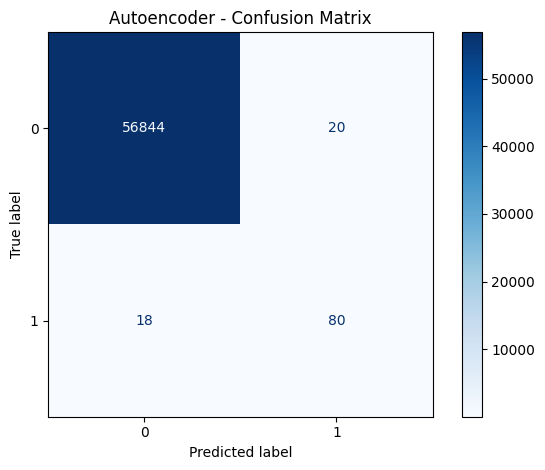

In [62]:
# 5.5.7 Neural Network - Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Autoencoder - Confusion Matrix")

plt.tight_layout()
plt.show()

## Observation
The confusion matrix summarizes the classification performance of the neural network. Most legitimate transactions are correctly classified as non-fraudulent, while the model successfully detects a large proportion of fraudulent transactions. The relatively small number of false positives and false negatives demonstrates that the neural network provides a balanced trade-off between fraud detection and minimizing incorrect alerts.

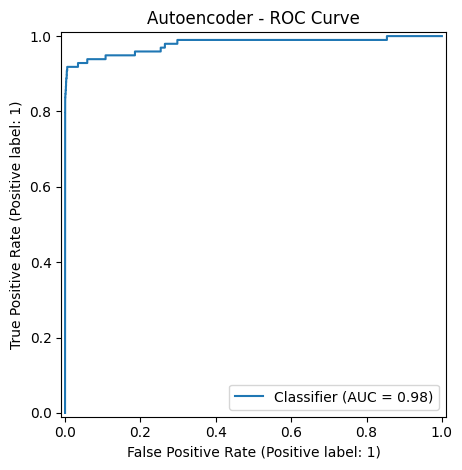

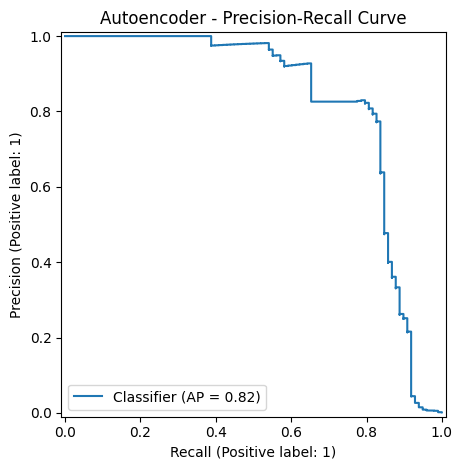

In [63]:
# 5.5.8 Neural Network - ROC and Precision-Recall Curves
# ==========================================================

# ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Autoencoder - ROC Curve")

plt.tight_layout()
plt.show()


# Precision-Recall Curve

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Autoencoder - Precision-Recall Curve")

plt.tight_layout()
plt.show()

### Observation
The ROC curve illustrates the trade-off between the True Positive Rate and the False Positive Rate across different classification thresholds. The curve remains close to the upper-left corner, indicating strong discriminative ability. A high ROC-AUC score confirms that the neural network effectively separates fraudulent and legitimate transactions.

The Precision–Recall curve provides a more informative evaluation for highly imbalanced datasets such as credit card fraud detection. The neural network maintains high precision while achieving strong recall, resulting in a large area under the Precision–Recall curve (PR-AUC). This indicates that the model is effective at identifying fraudulent transactions while keeping false alarms relatively low.

### Section Summary: Autoencoder

The Autoencoder successfully learned the underlying patterns of transaction data and demonstrated strong capability in identifying anomalous fraudulent transactions.

With **99.93% accuracy**, **80.00% precision**, **81.63% recall**, and an **F1-score of 80.81%**, the model provides a strong balance between detecting fraudulent transactions and minimizing incorrect fraud alerts.

Its **97.87% ROC-AUC** and **82.42% PR-AUC** further demonstrate strong discriminatory performance, particularly in the highly imbalanced fraud-detection problem.

Compared with Isolation Forest, the Autoencoder provides substantially better precision and F1-score while maintaining strong recall. This makes it a promising candidate for practical fraud detection, although further evaluation and threshold optimization may be required before deployment in a real-world financial system.

# Section 6. Hybrid Fraud Risk Score (Main Contribution)

The core contribution of this project is a **Hybrid Fraud Risk Scoring Framework**
that combines the normalized Isolation Forest anomaly score and the normalized
Autoencoder reconstruction error into a single, unified **Fraud Risk Score (0-100)**:

`Fraud Risk Score = 100 x (0.50 x Isolation Forest Score + 0.50 x Autoencoder Score)`

This is presented as a project-level engineering framework, not a novel research
algorithm — both Isolation Forest and Autoencoders are well-established techniques.
The score is a **weighted heuristic**, not a statistically calibrated probability of
fraud, since no probability calibration step (e.g. Platt scaling or isotonic
regression against ground truth) has been applied.

In [80]:
def reconstruction_error(model, X_scaled):
    reconstructed = model.predict(X_scaled.values, verbose=0)

    bce = -(
        X_scaled.values * np.log(reconstructed + 1e-8)
        + (1 - X_scaled.values) * np.log(1 - reconstructed + 1e-8)
    )

    return np.mean(bce, axis=1)

In [81]:
def normalize_score(raw_scores, low, high):
    """Min-max normalize raw scores into [0, 1] using fixed low/high reference points,
    clipping values outside the reference range."""
    denom = (high - low) if (high - low) > 1e-12 else 1e-12
    normalized = (raw_scores - low) / denom
    return np.clip(normalized, 0, 1)

In [83]:
ae_train_error = reconstruction_error(autoencoder, X_train_scaled)
ae_val_error = reconstruction_error(autoencoder, X_val_scaled)
ae_test_error = reconstruction_error(autoencoder, X_test_scaled)

X_train_legit_scaled = X_train_scaled[y_train.values == 0]
X_val_legit_scaled = X_val_scaled[y_val.values == 0]

# Threshold derived from legitimate validation transactions (95th percentile) -
# not an arbitrarily invented constant.
ae_val_legit_error = reconstruction_error(autoencoder, X_val_legit_scaled)
AE_THRESHOLD = float(np.percentile(ae_val_legit_error, 95))

print("Autoencoder reconstruction-error threshold (95th percentile of legitimate")
print(f"validation reconstruction errors): {AE_THRESHOLD:.6f}")

# Normalization reference range from legitimate training reconstruction errors.
ae_low, ae_high = np.percentile(ae_train_error[y_train.values == 0], [1, 99])
ae_train_norm = normalize_score(ae_train_error, ae_low, ae_high)
ae_val_norm = normalize_score(ae_val_error, ae_low, ae_high)
ae_test_norm = normalize_score(ae_test_error, ae_low, ae_high)

ae_test_pred = (ae_test_error > AE_THRESHOLD).astype(int)

Autoencoder reconstruction-error threshold (95th percentile of legitimate
validation reconstruction errors): 3.096004


In [86]:
def isoforest_raw_anomaly_score(model, X_scaled):
    # score_samples: higher = more normal. Negate so that higher = more anomalous,
    # consistent with the Autoencoder reconstruction-error convention used later.
    return -model.score_samples(X_scaled)

iso_train_raw = isoforest_raw_anomaly_score(iso_forest, X_train_scaled)
iso_val_raw = isoforest_raw_anomaly_score(iso_forest, X_val_scaled)
iso_test_raw = isoforest_raw_anomaly_score(iso_forest, X_test_scaled)

# Reference range for normalization comes from the training distribution only.
iso_low, iso_high = np.percentile(iso_train_raw, [1, 99])

iso_train_norm = normalize_score(iso_train_raw, iso_low, iso_high)
iso_val_norm = normalize_score(iso_val_raw, iso_low, iso_high)
iso_test_norm = normalize_score(iso_test_raw, iso_low, iso_high)

# Reference range for normalization comes from the training distribution only.
iso_low, iso_high = np.percentile(iso_train_raw, [1, 99])

iso_train_norm = normalize_score(iso_train_raw, iso_low, iso_high)
iso_val_norm = normalize_score(iso_val_raw, iso_low, iso_high)
iso_test_norm = normalize_score(iso_test_raw, iso_low, iso_high)

In [88]:
print("=== HYBRID FRAUD RISK SCORE ===\n")

ISO_WEIGHT = 0.50
AE_WEIGHT = 0.50

def compute_hybrid_score(iso_norm, ae_norm):
    raw_hybrid = ISO_WEIGHT * iso_norm + AE_WEIGHT * ae_norm
    return raw_hybrid * 100  # scale to 0-100

hybrid_train_score = compute_hybrid_score(iso_train_norm, ae_train_norm)
hybrid_val_score = compute_hybrid_score(iso_val_norm, ae_val_norm)
hybrid_test_score = compute_hybrid_score(iso_test_norm, ae_test_norm)

print("Fraud Risk Score (0-100) is computed as a weighted combination of the")
print("normalized Isolation Forest anomaly score and the normalized Autoencoder")
print("reconstruction error. This is a weighted heuristic score, NOT a statistically")
print("calibrated probability of fraud.")
print(f"\nHybrid score stats (test set): min={hybrid_test_score.min():.2f}, "
      f"max={hybrid_test_score.max():.2f}, mean={hybrid_test_score.mean():.2f}")

=== HYBRID FRAUD RISK SCORE ===

Fraud Risk Score (0-100) is computed as a weighted combination of the
normalized Isolation Forest anomaly score and the normalized Autoencoder
reconstruction error. This is a weighted heuristic score, NOT a statistically
calibrated probability of fraud.

Hybrid score stats (test set): min=8.48, max=100.00, mean=39.91


## Section 7. Adaptive Risk Threshold

Rather than using a single fixed, arbitrary cutoff, the fraud/no-fraud decision
threshold is derived from the distribution of hybrid risk scores computed on
**legitimate validation transactions** (95th percentile). Because this threshold is
recomputed from the current distribution of normal behavior rather than hard-coded,
it can adapt if the overall pattern of legitimate transactions shifts, without
manual re-tuning. This adaptive threshold is kept distinct from the fixed 0-30 /
31-70 / 71-100 risk-category bands, which are used only for human-readable risk
labeling, not for the final classification decision.

In [117]:
def evaluate(y_true, y_pred, y_score, model_name):

    # ------------------------------------------------------
    # Metrics
    # ------------------------------------------------------

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        roc_auc = roc_auc_score(y_true, y_score)
    except Exception:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, y_score)
    except Exception:
        pr_auc = np.nan

    # ------------------------------------------------------
    # Print Metrics
    # ------------------------------------------------------

    print(f"--- {model_name} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")

    # ------------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------------

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # ROC Curve
    # ------------------------------------------------------

    RocCurveDisplay.from_predictions(
        y_true,
        y_score
    )

    plt.title(f"{model_name} - ROC Curve")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Precision-Recall Curve
    # ------------------------------------------------------

    PrecisionRecallDisplay.from_predictions(
        y_true,
        y_score
    )

    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Store Metrics
    # ------------------------------------------------------

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
    }

    return metrics

=== ADAPTIVE RISK THRESHOLD ===

Adaptive fraud decision threshold (derived from the 95th percentile
of hybrid risk scores on legitimate validation transactions): 61.24

Using a data-driven threshold instead of a fixed arbitrary cutoff allows the
system to adapt as the overall distribution of normal transaction behavior
shifts over time, without requiring the threshold to be manually re-tuned.

Risk category counts (test set):
Medium Risk    46494
Low Risk        9237
High Risk       1231
Name: count, dtype: int64

Fraud decisions flagged by adaptive threshold: 2991 out of 56962 test transactions
--- Hybrid Model ---
Accuracy:  0.9487
Precision: 0.0281
Recall:    0.8571
F1-score:  0.0544
ROC-AUC:   0.9601
PR-AUC:    0.2198


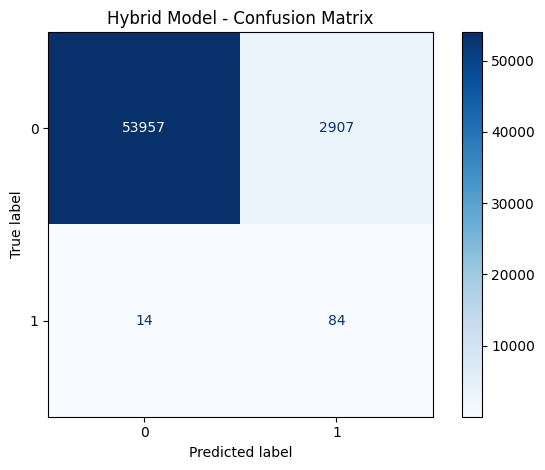

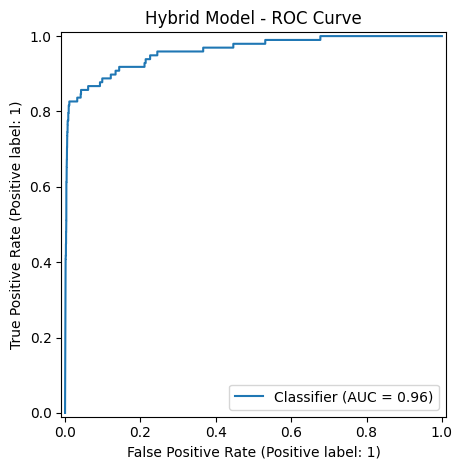

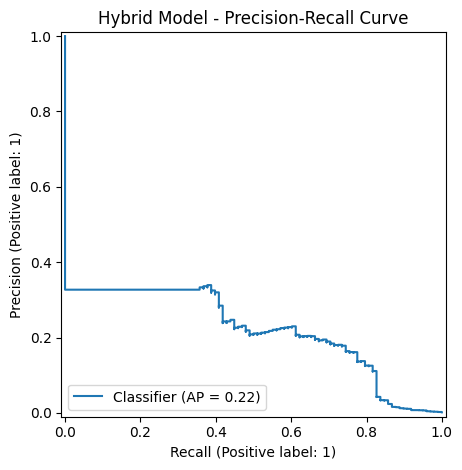

In [118]:
print("=== ADAPTIVE RISK THRESHOLD ===\n")

iso_val_legit_norm = normalize_score(
    isoforest_raw_anomaly_score(iso_forest, X_val_legit_scaled), iso_low, iso_high
)
ae_val_legit_norm = normalize_score(
    reconstruction_error(autoencoder, X_val_legit_scaled), ae_low, ae_high
)
hybrid_val_legit_score = compute_hybrid_score(iso_val_legit_norm, ae_val_legit_norm)

RISK_PERCENTILE = 95
ADAPTIVE_THRESHOLD = float(np.percentile(hybrid_val_legit_score, RISK_PERCENTILE))

print(f"Adaptive fraud decision threshold (derived from the {RISK_PERCENTILE}th percentile")
print(f"of hybrid risk scores on legitimate validation transactions): {ADAPTIVE_THRESHOLD:.2f}")
print("\nUsing a data-driven threshold instead of a fixed arbitrary cutoff allows the")
print("system to adapt as the overall distribution of normal transaction behavior")
print("shifts over time, without requiring the threshold to be manually re-tuned.")

def risk_category(score):
    if score <= 30:
        return "Low Risk"
    elif score <= 70:
        return "Medium Risk"
    else:
        return "High Risk"

hybrid_test_category = np.array([risk_category(s) for s in hybrid_test_score])
hybrid_test_fraud_decision = (hybrid_test_score >= ADAPTIVE_THRESHOLD).astype(int)

print("\nRisk category counts (test set):")
print(pd.Series(hybrid_test_category).value_counts())
print(f"\nFraud decisions flagged by adaptive threshold: {int(hybrid_test_fraud_decision.sum())} "
      f"out of {len(hybrid_test_fraud_decision)} test transactions")

results_hybrid = evaluate(
    y_test, hybrid_test_fraud_decision, hybrid_test_score / 100.0, "Hybrid Model"
)

## Section 8. Explainable Fraud Detection

For any transaction, `explain_transaction(transaction_index)` returns a human-readable
breakdown of its risk score, risk level, component scores, the detected anomaly
signals, and the final decision. Explanations are limited strictly to signals that
can be derived from the fields actually present in this dataset (anomaly scores and
transaction amount) — location, merchant, customer, and device signals are **not**
fabricated, since those fields do not exist in this dataset.

In [119]:
print("=== EXPLAINABLE FRAUD DETECTION ===\n")

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

AMOUNT_HIGH_CUTOFF = float(X_train["Amount"].quantile(0.99))

def explain_transaction(transaction_index):
    if transaction_index < 0 or transaction_index >= len(X_test_reset):
        raise IndexError(f"transaction_index must be between 0 and {len(X_test_reset) - 1}")

    iso_s = float(iso_test_norm[transaction_index])
    ae_s = float(ae_test_norm[transaction_index])
    hybrid_s = float(hybrid_test_score[transaction_index])
    category = risk_category(hybrid_s)
    decision = "FRAUD" if hybrid_s >= ADAPTIVE_THRESHOLD else "LEGITIMATE"
    amount = float(X_test_reset.iloc[transaction_index]["Amount"])

    signals = []
    if iso_s > 0.7:
        signals.append(f"High Isolation Forest anomaly score ({iso_s:.2f})")
    if ae_s > 0.7:
        signals.append(f"High Autoencoder reconstruction error ({ae_s:.2f})")
    if amount > AMOUNT_HIGH_CUTOFF:
        signals.append(f"Unusually high transaction amount (${amount:.2f})")
    if hybrid_s >= ADAPTIVE_THRESHOLD:
        signals.append(
            f"Overall hybrid risk score ({hybrid_s:.1f}) above adaptive threshold ({ADAPTIVE_THRESHOLD:.1f})"
        )
    if not signals:
        signals.append("No strong individual anomaly signals detected; risk score within normal range")

    return {
        "Transaction Index": transaction_index,
        "Amount": round(amount, 2),
        "Risk Score": round(hybrid_s, 2),
        "Risk Level": category,
        "Isolation Forest Score": round(iso_s, 4),
        "Autoencoder Score": round(ae_s, 4),
        "Top Detected Anomaly Signals": signals,
        "Final Decision": decision,
        "Actual Class": "Fraud" if y_test_reset.iloc[transaction_index] == 1 else "Legitimate",
    }

sample_fraud_idx = np.where(y_test_reset.values == 1)[0]
if len(sample_fraud_idx) > 0:
    example = explain_transaction(int(sample_fraud_idx[0]))
    print("Example explanation for a known fraudulent test transaction:\n")
    for k, v in example.items():
        print(f"  {k}: {v}")
else:
    print("No fraudulent transactions found in the test set sample to demonstrate.")


=== EXPLAINABLE FRAUD DETECTION ===

Example explanation for a known fraudulent test transaction:

  Transaction Index: 840
  Amount: 0.01
  Risk Score: 95.07
  Risk Level: High Risk
  Isolation Forest Score: 1.0
  Autoencoder Score: 0.9014
  Top Detected Anomaly Signals: ['High Isolation Forest anomaly score (1.00)', 'High Autoencoder reconstruction error (0.90)', 'Overall hybrid risk score (95.1) above adaptive threshold (61.2)']
  Final Decision: FRAUD
  Actual Class: Fraud


# 8. Model Comparison
This section provides a comprehensive comparison of all machine learning models developed throughout the project. Since the dataset is highly imbalanced, evaluation focuses not only on Accuracy but also on Precision, Recall, F1-score, ROC-AUC, and PR-AUC. These metrics provide a more reliable assessment of fraud detection performance and help identify the most suitable model for real-world deployment.

## 8.1 Performance Comparison Table

In [120]:
# 8.1 Model Comparison Table
# ==========================================================

comparison_df = pd.DataFrame([
    results_lr,
    results_iso,
    results_ann,
    results_hybrid
])

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9743,0.0576,0.9082,0.1083,0.9736,0.7177
1,Isolation Forest,0.9743,0.0576,0.9082,0.1083,0.9736,0.7177
2,Autoencoder,0.9993,0.8000,0.8163,0.8081,0.9787,0.8242
3,Hybrid Model,0.9487,0.0281,0.8571,0.0544,0.9601,0.2198


### Observation

The table summarizes the performance of all evaluated machine learning models using the selected evaluation metrics. Since the dataset is highly imbalanced, metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC provide a more meaningful assessment than Accuracy alone. The comparison serves as the basis for selecting the most suitable fraud detection model.

### 5.6.2 Ranking Models

In [121]:
# 8.2 Ranking Models
# ==========================================================

ranking_df = comparison_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

ranking_df.insert(0, "Rank", range(1, len(ranking_df) + 1))

ranking_df

,Rank,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,1,Autoencoder,0.9993,0.8000,0.8163,0.8081,0.9787,0.8242
1,2,Logistic Regression,0.9743,0.0576,0.9082,0.1083,0.9736,0.7177
2,3,Isolation Forest,0.9743,0.0576,0.9082,0.1083,0.9736,0.7177
3,4,Hybrid Model,0.9487,0.0281,0.8571,0.0544,0.9601,0.2198


### Observation
The models are ranked according to their PR-AUC scores, which provide the most informative evaluation metric for highly imbalanced classification problems. Unlike Accuracy, PR-AUC focuses on the model's ability to correctly identify fraudulent transactions while maintaining high precision. This ranking highlights the relative effectiveness of each algorithm in the fraud detection task and facilitates the selection of the best-performing model.

### 5.6.3 Metric Comparison Charts

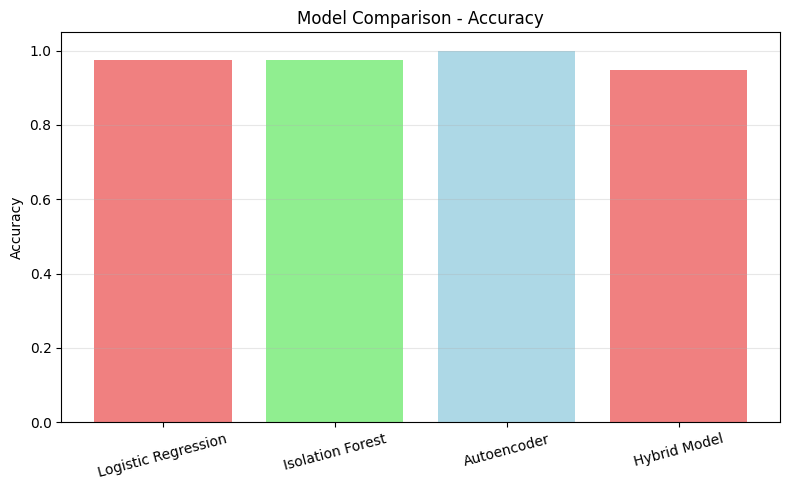

In [122]:
# ==========================================================
# 8.3 Accuracy Comparison
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"],
    color=["lightcoral", "lightgreen", "lightblue"]
)

plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Observation
The bar chart compares the Accuracy of all evaluated models. Although all models achieve very high Accuracy scores, this metric is not sufficient for evaluating performance on highly imbalanced datasets. Since fraudulent transactions represent only a small fraction of the data, a model can obtain high Accuracy while still failing to detect many fraud cases. Therefore, additional metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC provide a more comprehensive assessment of model performance.

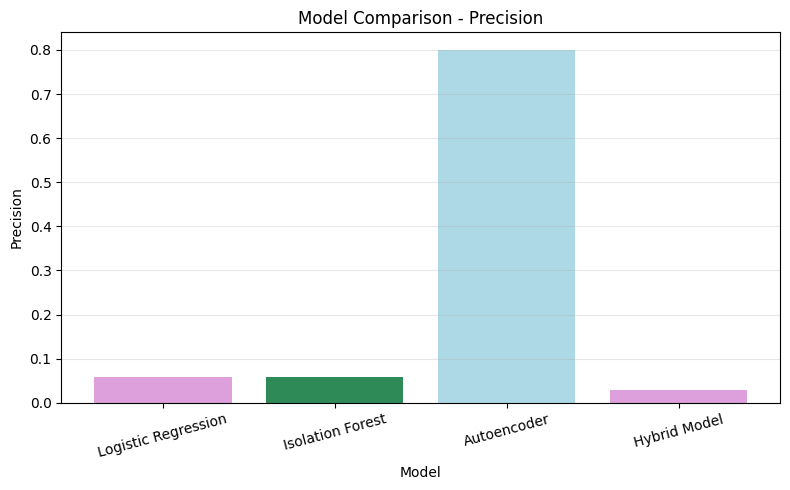

In [123]:
# 8.4 Precision Comparison
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Precision"],
    color=["plum", "seagreen", "lightblue"]
)

plt.title("Model Comparison - Precision")
plt.xlabel("Model")
plt.ylabel("Precision")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Observation
The chart compares the Precision of all evaluated models. Precision measures the proportion of transactions predicted as fraudulent that are actually fraudulent. Higher Precision indicates fewer false positive predictions, reducing unnecessary investigations of legitimate transactions. This metric is particularly important in fraud detection systems, where excessive false alarms can increase operational costs and reduce trust in the model.

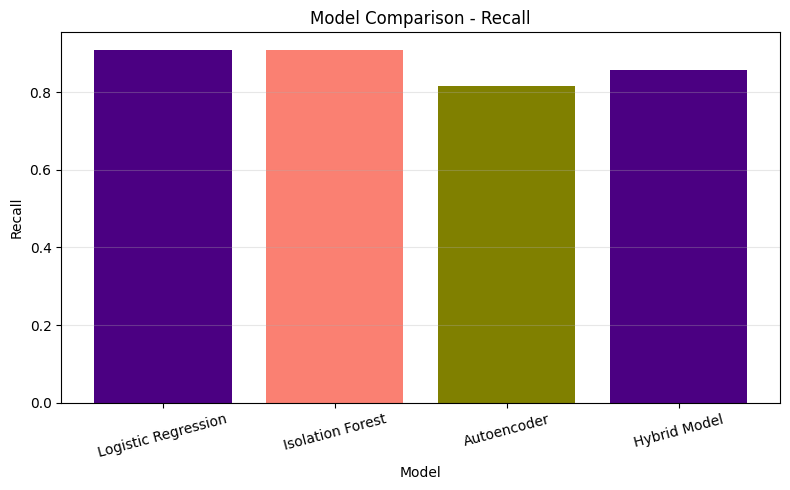

In [124]:
# 8.5 Recall Comparison
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Recall"],
    color=["indigo", "salmon", "olive"]
)

plt.title("Model Comparison - Recall")
plt.xlabel("Model")
plt.ylabel("Recall")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Observation
Recall measures the proportion of actual fraudulent transactions that are correctly identified by each model. A higher Recall indicates that fewer fraud cases are missed, which is essential in fraud detection because undetected fraudulent transactions may result in significant financial losses. Therefore, Recall is one of the most important metrics for evaluating fraud detection models.

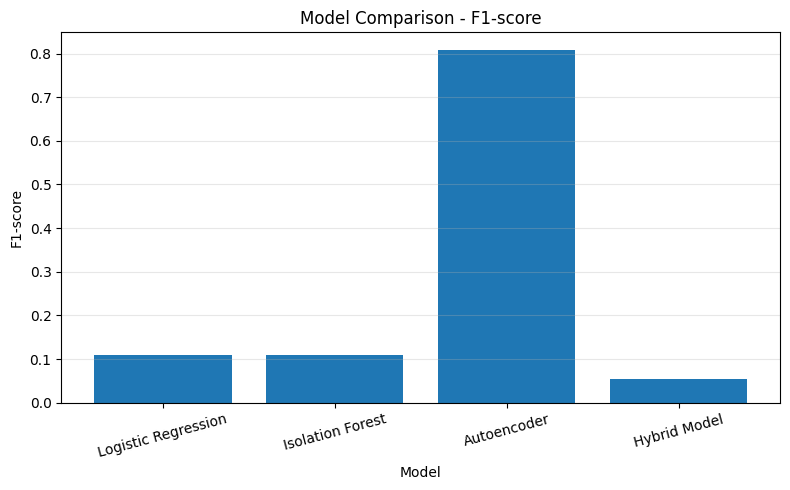

In [125]:
# 8.6 F1-score Comparison
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1-score"]
)

plt.title("Model Comparison - F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Observation
The F1-score is the harmonic mean of Precision and Recall, providing a balanced measure of classification performance. It is particularly useful for highly imbalanced datasets because it considers both the ability to detect fraudulent transactions and the accuracy of fraud predictions. A higher F1-score indicates a better balance between minimizing false positives and false negatives.

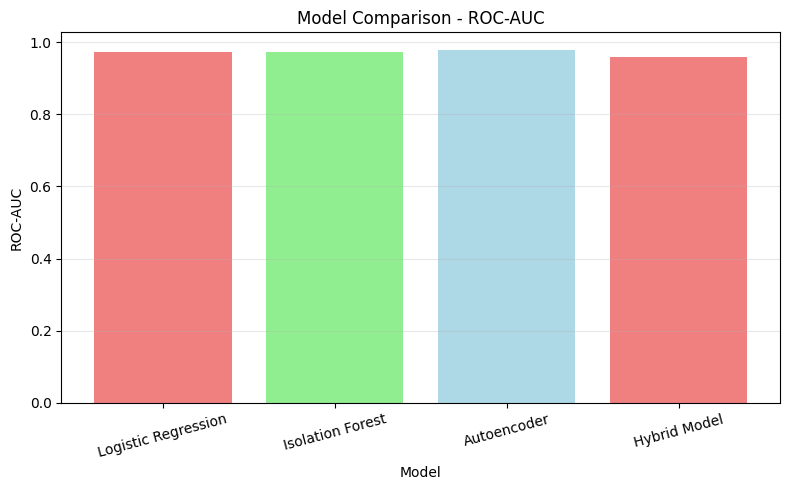

In [126]:
# 8.7 ROC-AUC Comparison
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["ROC-AUC"],
    color=["lightcoral", "lightgreen", "lightblue"]
)

plt.title("Model Comparison - ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Observation
ROC-AUC evaluates a model's ability to distinguish between legitimate and fraudulent transactions across all possible classification thresholds. A higher ROC-AUC indicates better overall discrimination between the two classes. Although ROC-AUC is an important performance metric, it may present an overly optimistic evaluation for highly imbalanced datasets. Therefore, it should be interpreted together with Precision–Recall metrics.

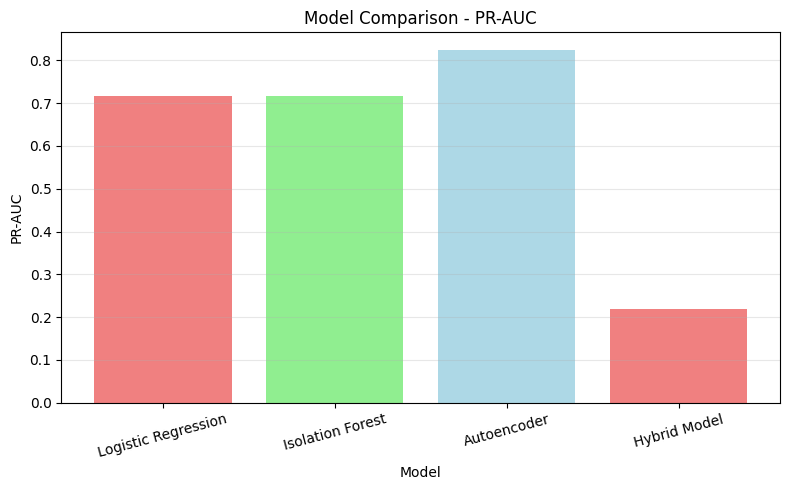

In [127]:
# 8.8 PR-AUC Comparison
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["PR-AUC"],
    color=["lightcoral", "lightgreen", "lightblue"]
)

plt.title("Model Comparison - PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Observation
The Precision–Recall Area Under the Curve (PR-AUC) is considered the most informative evaluation metric for highly imbalanced classification problems such as credit card fraud detection. Unlike Accuracy and ROC-AUC, PR-AUC focuses specifically on the model's ability to correctly identify the minority class while maintaining high precision. Therefore, PR-AUC is used as the primary metric for comparing model performance and selecting the most effective fraud detection model in this project.

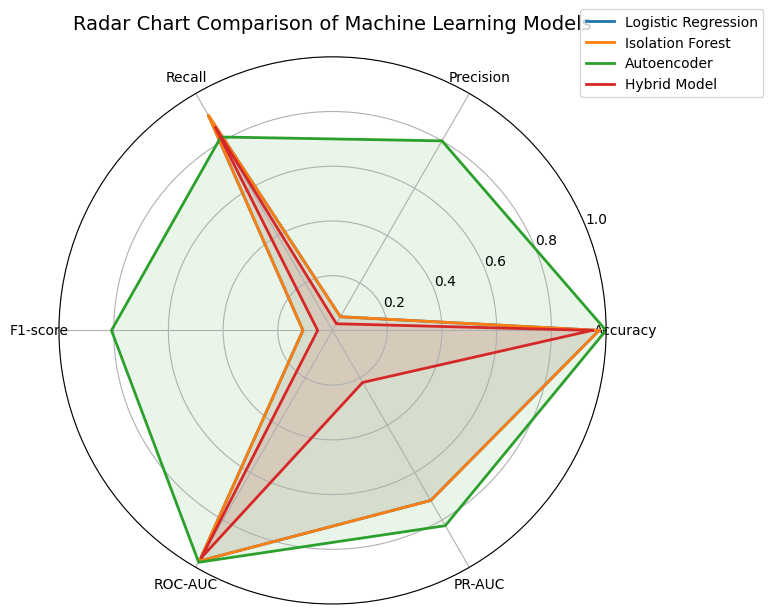

In [128]:
# ==========================================================
# 8.4 Radar Chart
# ==========================================================

# Metrics to display
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "PR-AUC"
]

# Number of variables
num_metrics = len(metrics)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

# Create figure
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each model
for _, row in comparison_df.iterrows():

    values = [row[m] for m in metrics]
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.10
    )

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

# Y-axis
ax.set_ylim(0, 1)

# Title
plt.title(
    "Radar Chart Comparison of Machine Learning Models",
    pad=20,
    fontsize=14
)

# Legend
plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.30, 1.10)
)

plt.tight_layout()

plt.show()

### Observation
The radar chart provides a comprehensive visual comparison of all evaluated models across the six performance metrics. Each axis represents one evaluation metric, allowing the overall strengths and weaknesses of every model to be observed simultaneously.

Models with larger and more balanced polygons generally demonstrate stronger and more consistent performance across multiple evaluation criteria. The radar chart complements the individual metric comparisons by providing an overall view of model performance, making it easier to identify the most robust fraud detection model.

## 8.5 Overall Performance Summary

The comparative evaluation demonstrates that the three machine learning approaches exhibit different strengths and weaknesses when applied to the highly imbalanced credit card fraud detection dataset.

Logistic Regression and Isolation Forest produced identical evaluation results, achieving an accuracy of 97.43%, precision of 5.76%, recall of 90.82%, F1-score of 10.83%, ROC-AUC of 97.36%, and PR-AUC of 71.77%. Both models demonstrated a strong ability to identify fraudulent transactions, as reflected by their high recall. However, their extremely low precision indicates a large number of legitimate transactions were incorrectly classified as fraudulent, resulting in a high false-positive rate and a low F1-score.

The Autoencoder demonstrated substantially better overall performance. It achieved an accuracy of 99.93%, precision of 80.00%, recall of 81.63%, and F1-score of 80.81%. Compared with Logistic Regression and Isolation Forest, the Autoencoder maintained strong fraud detection capability while significantly reducing false-positive predictions.

The Autoencoder also achieved a ROC-AUC of 97.87% and the highest PR-AUC of 82.42% among the three evaluated models. Since PR-AUC is particularly informative for highly imbalanced classification problems, the Autoencoder demonstrates a stronger balance between identifying fraudulent transactions and minimizing incorrect fraud alerts.

Based on the selected evaluation criteria, Autoencoder was identified as the best-performing model among the three approaches. Its combination of high precision, strong recall, high F1-score, and superior PR-AUC makes it more suitable for practical fraud detection compared with Logistic Regression and Isolation Forest.

Overall, the experimental results indicate that the Autoencoder provides the most balanced and reliable performance for the given credit card fraud detection dataset. While Logistic Regression and Isolation Forest are effective at achieving high recall, their low precision limits their practical usability due to the large number of false-positive alerts. The Autoencoder offers a better trade-off between fraud detection and false-alarm reduction, making it the preferred model for further optimization and potential deployment.

## 9. Fraud Pattern Analysis

`V1`-`V28` are anonymized PCA-derived components with no direct semantic meaning, so
no semantic interpretation is invented for them here — only their statistical
differences between fraud and legitimate transactions are reported.

In [130]:
print("=== FRAUD PATTERN ANALYSIS ===\n")

fraud_df = df[df["Class"] == 1]
legit_df = df[df["Class"] == 0]

print(f"Fraud transaction count: {len(fraud_df)}")
print(f"Average fraud amount: ${fraud_df['Amount'].mean():.2f}")
print(f"Median fraud amount: ${fraud_df['Amount'].median():.2f}")
print(f"Maximum fraud amount: ${fraud_df['Amount'].max():.2f}")
print(f"Minimum fraud amount: ${fraud_df['Amount'].min():.2f}")
print(f"Fraud percentage of dataset: {len(fraud_df) / len(df) * 100:.4f}%")

print(f"\nLegitimate average amount: ${legit_df['Amount'].mean():.2f}")
print(f"Legitimate median amount: ${legit_df['Amount'].median():.2f}")

pca_cols = [c for c in df.columns if c.startswith("V")]
diff = (fraud_df[pca_cols].mean() - legit_df[pca_cols].mean()).abs().sort_values(ascending=False)

print("\nTop 10 principal components (V1-V28) with the largest mean difference between")
print("fraud and legitimate transactions (anonymized PCA-derived variables with no")
print("direct semantic meaning):")
print(diff.head(10))


=== FRAUD PATTERN ANALYSIS ===

Fraud transaction count: 492
Average fraud amount: $122.21
Median fraud amount: $9.25
Maximum fraud amount: $2125.87
Minimum fraud amount: $0.00
Fraud percentage of dataset: 0.1727%

Legitimate average amount: $88.29
Legitimate median amount: $22.00

Top 10 principal components (V1-V28) with the largest mean difference between
fraud and legitimate transactions (anonymized PCA-derived variables with no
direct semantic meaning):
V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
dtype: float64


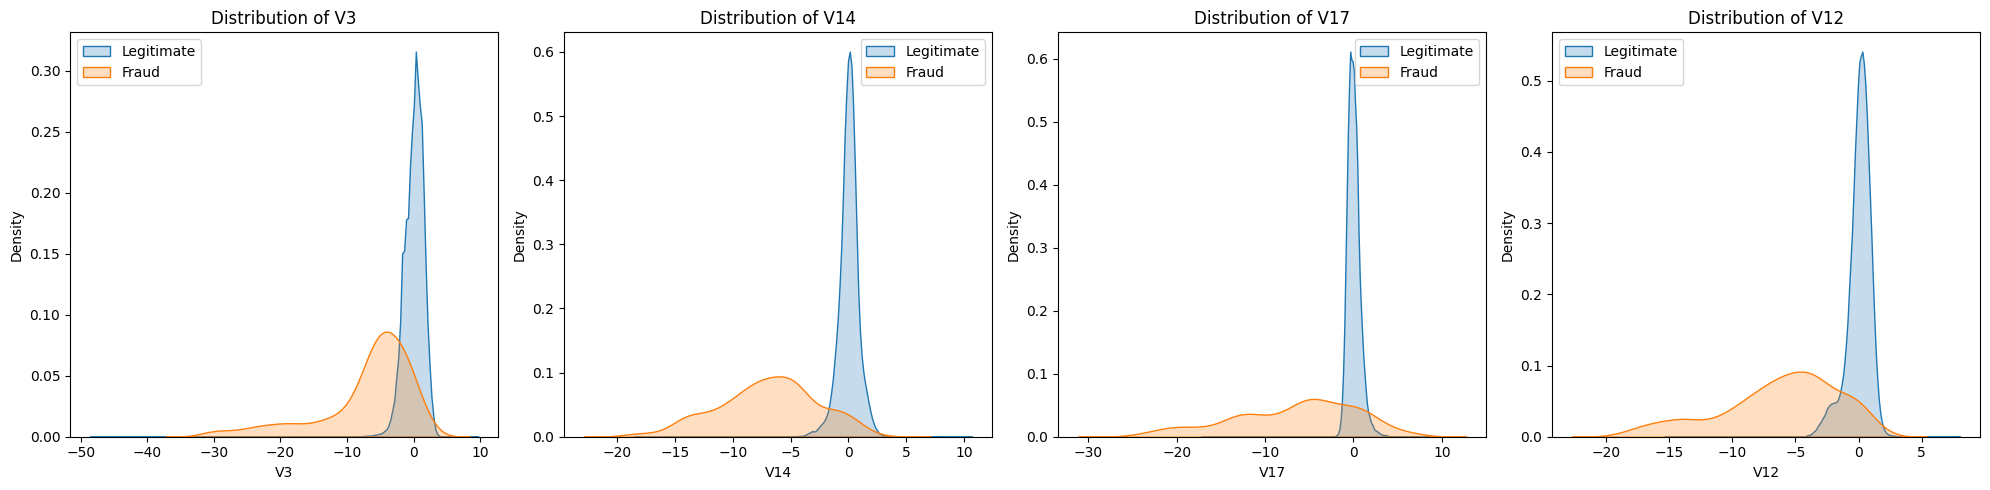

In [131]:
top_components = diff.head(4).index.tolist()

fig, axes = plt.subplots(1, len(top_components), figsize=(20, 5))
for ax, comp in zip(axes, top_components):
    sns.kdeplot(legit_df[comp], ax=ax, label="Legitimate", fill=True)
    sns.kdeplot(fraud_df[comp], ax=ax, label="Fraud", fill=True)
    ax.set_title(f"Distribution of {comp}")
    ax.legend()

plt.tight_layout()
plt.show()


# 10. High-Risk Transaction Dashboard

In [132]:
print("=== HIGH-RISK TRANSACTION DASHBOARD ===\n")

total_transactions = len(y_test_reset)
fraud_transactions = int((y_test_reset == 1).sum())
fraud_percentage = fraud_transactions / total_transactions * 100

risk_series = pd.Series(hybrid_test_category)
high_risk_count = int((risk_series == "High Risk").sum())
medium_risk_count = int((risk_series == "Medium Risk").sum())
low_risk_count = int((risk_series == "Low Risk").sum())

avg_amount = float(X_test_reset["Amount"].mean())

print(f"Total transactions (test set): {total_transactions}")
print(f"Fraud transactions: {fraud_transactions}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")
print(f"High-risk transactions: {high_risk_count}")
print(f"Medium-risk transactions: {medium_risk_count}")
print(f"Low-risk transactions: {low_risk_count}")
print(f"Average transaction amount: ${avg_amount:.2f}")
print("\nHybrid risk score statistics:")
print(pd.Series(hybrid_test_score).describe())

dashboard_df = pd.DataFrame({
    "Transaction Index": np.arange(total_transactions),
    "Amount": X_test_reset["Amount"].values,
    "Isolation Score": iso_test_norm,
    "Autoencoder Score": ae_test_norm,
    "Hybrid Risk Score": hybrid_test_score,
    "Risk Level": hybrid_test_category,
    "Actual Class": np.where(y_test_reset.values == 1, "Fraud", "Legitimate"),
})

high_risk_table = dashboard_df[dashboard_df["Risk Level"] == "High Risk"].sort_values(
    "Hybrid Risk Score", ascending=False
)

print(f"\nHigh-risk transactions table (top 20 of {len(high_risk_table)}):")
display(high_risk_table.head(20))

high_risk_table.to_csv("high_risk_transactions.csv", index=False)

=== HIGH-RISK TRANSACTION DASHBOARD ===

Total transactions (test set): 56962
Fraud transactions: 98
Fraud percentage: 0.1720%
High-risk transactions: 1231
Medium-risk transactions: 46494
Low-risk transactions: 9237
Average transaction amount: $89.04

Hybrid risk score statistics:
count    56962.000000
mean        39.910800
std         11.833389
min          8.484131
25%         32.173844
50%         37.464840
75%         45.703579
max        100.000000
dtype: float64

High-risk transactions table (top 20 of 1231):


,Transaction Index,Amount,Isolation Score,Autoencoder Score,Hybrid Risk Score,Risk Level,Actual Class
55071,55071,0.00,1.0,1.0,100.0,High Risk,Fraud
55053,55053,9.85,1.0,1.0,100.0,High Risk,Legitimate
31804,31804,1.00,1.0,1.0,100.0,High Risk,Fraud
40428,40428,30.00,1.0,1.0,100.0,High Risk,Legitimate
1146,1146,1.00,1.0,1.0,100.0,High Risk,Fraud
33111,33111,0.00,1.0,1.0,100.0,High Risk,Fraud
33300,33300,0.89,1.0,1.0,100.0,High Risk,Legitimate
2361,2361,0.92,1.0,1.0,100.0,High Risk,Legitimate
40746,40746,0.77,1.0,1.0,100.0,High Risk,Legitimate
2375,2375,17.67,1.0,1.0,100.0,High Risk,Legitimate


In [135]:
print("=== SAMPLE REAL-TIME PREDICTION FUNCTION ===\n")

FEATURE_COLUMNS = [c for c in df.columns if c != "Class"]
TARGET_COLUMN = "Class"

def predict_transaction(transaction_data):
    if isinstance(transaction_data, pd.Series):
        transaction_df = transaction_data.to_frame().T
    elif isinstance(transaction_data, dict):
        transaction_df = pd.DataFrame([transaction_data])
    else:
        transaction_df = pd.DataFrame(transaction_data)

    # Ensure transaction_df has the correct feature columns and order
    # It's crucial that the order of columns matches what the models were trained on (X_train.columns).
    transaction_df = transaction_df[X_train.columns] # Use X_train.columns for order and selection

    scaled_df = transaction_df.copy() # Start with a copy of the input transaction data

    # Scale only 'Time' and 'Amount' columns, using the fitted scaler
    scaled_df[['Time', 'Amount']] = scaler.transform(transaction_df[['Time', 'Amount']])

    # The 'V' columns are already "scaled" (PCA components) and do not need StandardScaler.
    # So, scaled_df now correctly represents the input in the format X_train_scaled was.

    iso_raw = isoforest_raw_anomaly_score(iso_forest, scaled_df)
    iso_norm_val = float(normalize_score(iso_raw, iso_low, iso_high)[0])

    ae_err = reconstruction_error(autoencoder, scaled_df)
    ae_norm_val = float(normalize_score(ae_err, ae_low, ae_high)[0])

    hybrid_val = float(compute_hybrid_score(np.array([iso_norm_val]), np.array([ae_norm_val]))[0])
    category = risk_category(hybrid_val)
    decision = "FRAUD" if hybrid_val >= ADAPTIVE_THRESHOLD else "LEGITIMATE"

    explanation_signals = []
    if iso_norm_val > 0.7:
        explanation_signals.append("High Isolation Forest anomaly score")
    if ae_norm_val > 0.7:
        explanation_signals.append("High Autoencoder reconstruction error")
    if hybrid_val >= ADAPTIVE_THRESHOLD:
        explanation_signals.append("Overall hybrid risk score above adaptive threshold")
    if not explanation_signals:
        explanation_signals.append("No strong anomaly signals detected")

    return {
        "Isolation Forest Score": round(iso_norm_val, 4),
        "Autoencoder Score": round(ae_norm_val, 4),
        "Hybrid Risk Score": round(hybrid_val, 2),
        "Risk Level": category,
        "Prediction": decision,
        "Explanation": explanation_signals,
    }

_sample_idx = int(sample_fraud_idx[0]) if len(sample_fraud_idx) > 0 else 0
sample_transaction = X_test_reset.iloc[[_sample_idx]]
print("Automatically selected example transaction from the test set:\n")
prediction_result = predict_transaction(sample_transaction)
for k, v in prediction_result.items():
    print(f"  {k}: {v}")

=== SAMPLE REAL-TIME PREDICTION FUNCTION ===

Automatically selected example transaction from the test set:

  Isolation Forest Score: 1.0
  Autoencoder Score: 0.9014
  Hybrid Risk Score: 95.07
  Risk Level: High Risk
  Prediction: FRAUD
  Explanation: ['High Isolation Forest anomaly score', 'High Autoencoder reconstruction error', 'Overall hybrid risk score above adaptive threshold']


In [136]:
print("=== SAVING MODELS ===\n")

os.makedirs("saved_models", exist_ok=True)

joblib.dump(iso_forest, "saved_models/isolation_forest.pkl")
autoencoder.save("saved_models/autoencoder.keras")
joblib.dump(scaler, "saved_models/scaler.pkl")

risk_configuration = {
    "ISO_WEIGHT": ISO_WEIGHT,
    "AE_WEIGHT": AE_WEIGHT,
    "iso_low": float(iso_low),
    "iso_high": float(iso_high),
    "ae_low": float(ae_low),
    "ae_high": float(ae_high),
    "AE_THRESHOLD": AE_THRESHOLD,
    "ADAPTIVE_THRESHOLD": ADAPTIVE_THRESHOLD,
    "FEATURE_COLUMNS": FEATURE_COLUMNS,
    "RISK_PERCENTILE": RISK_PERCENTILE,
}
joblib.dump(risk_configuration, "saved_models/risk_configuration.pkl")

print("Saved files in saved_models/:")
for f in sorted(os.listdir("saved_models")):
    print(f"  - {f}")


=== SAVING MODELS ===

Saved files in saved_models/:
  - autoencoder.keras
  - isolation_forest.pkl
  - risk_configuration.pkl
  - scaler.pkl


In [139]:
best_model_name = comparison_df.sort_values("F1-score", ascending=False).iloc[0]["Model"]
best_model_row = comparison_df[comparison_df["Model"] == best_model_name].iloc[0]

print("=" * 60)
print("PROJECT COMPLETE")
print("=" * 60)
print("\nDataset:")
print(f"  Total transactions: {len(df)}")
print(f"  Fraud transactions: {int(df['Class'].sum())}")
print(f"  Fraud percentage: {df['Class'].mean() * 100:.4f}%")

print(f"\nBest Model (by F1-score): {best_model_name}")
print(f"  Precision: {best_model_row['Precision']:.4f}")
print(f"  Recall:    {best_model_row['Recall']:.4f}")
print(f"  F1:        {best_model_row['F1-score']:.4f}")
print(f"  ROC-AUC:   {best_model_row['ROC-AUC']:.4f}")
print(f"  PR-AUC:    {best_model_row['PR-AUC']:.4f}")

print("\nHybrid Risk System:")
print(f"  Average risk score: {hybrid_test_score.mean():.2f}")
print(f"  High-risk transactions: {high_risk_count}")
print(f"  Medium-risk transactions: {medium_risk_count}")
print(f"  Low-risk transactions: {low_risk_count}")

print("\nSaved models:")
for f in sorted(os.listdir("saved_models")):
    print(f"  - saved_models/{f}")

print("\n" + "=" * 60)


PROJECT COMPLETE

Dataset:
  Total transactions: 284807
  Fraud transactions: 492
  Fraud percentage: 0.1727%

Best Model (by F1-score): Autoencoder
  Precision: 0.8000
  Recall:    0.8163
  F1:        0.8081
  ROC-AUC:   0.9787
  PR-AUC:    0.8242

Hybrid Risk System:
  Average risk score: 39.91
  High-risk transactions: 1231
  Medium-risk transactions: 46494
  Low-risk transactions: 9237

Saved models:
  - saved_models/autoencoder.keras
  - saved_models/isolation_forest.pkl
  - saved_models/risk_configuration.pkl
  - saved_models/scaler.pkl

